# TP Final: overfitting por selección

Implementación de [plan.md](plan.md). La tesis: la purged K-fold con embargo corrige el leakage, pero no el sesgo de selección. Si se prueban muchas configuraciones y se elige la mejor, igual se termina con un falso positivo.

## Cómo correrlo

Se abre desde la carpeta del repo (las rutas son relativas a esa carpeta) y se corre de arriba abajo. El entorno se arma así, y después se elige el kernel de `.venv`:

```
python -m venv .venv
.venv\Scripts\pip install -r requirements.txt
```

`requirements.txt` fija las versiones exactas de todos los paquetes con las que se corrió.

1. **Verificación** (`QUICK_RUN = True`, `RUN_HELDOUT = False`): grilla chica de 24 configuraciones (y 1 repetición del placebo, si `RUN_PLACEBO = True`). Todos los chequeos de la sección 7 tienen que pasar.
2. **Grilla completa** (`QUICK_RUN = False`): 1116 configuraciones, unos 20 minutos con 4 núcleos. Cada configuración se guarda en `cache/` apenas termina, así que si la corrida se corta, al volver a correr retoma donde quedó.
3. **Placebo** (`RUN_PLACEBO = True`): 10 repeticiones de la grilla sobre datos sin señal, unas 4 horas con 4 núcleos. Por eso viene desactivado y se activa a mano. Lo que ya se calculó queda en caché, así que se puede correr por partes.
4. Revisar los resultados de train y validación.
5. **Hold-out** (`RUN_HELDOUT = True`, con `QUICK_RUN = False`): evalúa 2018–2025. Se hace **una sola vez**, con todo lo anterior ya fijado.

Con `RUN_HELDOUT = False`, el panel de datos termina en diciembre de 2017, así que el código de train y validación no puede ver el hold-out ni por error. El notebook guardado en el repo está corrido con la grilla completa, sin placebo y sin hold-out.

## Reproducibilidad

- **Datos:** se bajan una sola vez y quedan en `data/`, que no se versiona (los datos de Yahoo no se pueden redistribuir). Yahoo revisa los precios ajustados con el tiempo, así que volver a bajarlos podría cambiar los resultados; el `DATA_HASH` del `manifest.json` permite verificar si dos corridas usaron exactamente los mismos datos. El CSV de integrantes del S&P 500 se baja de un commit fijo del repo.
- **Semillas:** todas salen de `SETTINGS['seed']`: Random Forest, desempates, placebo y sorteos de la curva.
- **Caché:** cada configuración se guarda en `cache/<CACHE_TAG>/`. `CACHE_TAG` es un hash de los parámetros que afectan los resultados por configuración, de los datos procesados y de las versiones de numpy y scikit-learn. Si cambia cualquiera de esas cosas, se usa otra carpeta. Con la grilla completa ocupa unos 150 MB.
- **Resultados:** todo lo que produce el notebook queda en `results/<RUN_TAG>/`: métricas por configuración (train, validación y hold-out), matrices de retornos, tablas, figuras, un `manifest.json` con la configuración, los hashes de los datos y las versiones de los paquetes, y un `pip_freeze.txt`.

In [1]:
# Lo único que se cambia a mano
RUN_HELDOUT = False  # True recién cuando todo lo demás esté verificado: evalúa el hold-out (2018-2025)
RUN_PLACEBO = False  # True para correr el placebo: 10 repeticiones, unas 4 horas con 4 núcleos (queda en caché)
QUICK_RUN = False    # True: grilla chica para verificar el código. False: grilla completa del plan
N_JOBS = -1          # procesos en paralelo para la grilla (-1 = todos los núcleos)

## 1. Configuración

Todos los parámetros del plan están en `SETTINGS`, y `QUICK` define la grilla chica de verificación. Cambiar cualquier valor de `SETTINGS` cambia el `RUN_TAG` (carpeta de resultados). Si además el valor afecta los resultados por configuración, cambia el `CACHE_TAG`, así que nunca se mezclan resultados de configuraciones distintas.

In [2]:
%matplotlib inline
import hashlib
import itertools
import json
import os
import platform
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import yfinance as yf
from joblib import Parallel, delayed
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

assert not (RUN_HELDOUT and QUICK_RUN), 'El hold-out se evalúa una sola vez, con la grilla completa (QUICK_RUN = False)'

In [3]:
SETTINGS = {
    'code_version': 1,  # subir si cambia la lógica de features, etiquetas o backtest: invalida el caché
    'seed': 20261003,
    'n_stocks': 40,
    'constituents_url': ('https://raw.githubusercontent.com/fja05680/sp500/a2430f2af0c79ddf0748e91de11bdeb1616ab5a7/'
                         'S%26P%20500%20Historical%20Components%20%26%20Changes%20(Updated).csv'),
    'universe_date': '2005-01-01',
    'min_coverage': 0.99,       # fracción mínima de días hábiles con precio entre 2005 y 2025
    # {'TICKER_DEL_CSV': 'TICKER_DE_YAHOO'} para empresas que siguen cotizando con otro símbolo (revisión manual)
    'universe_overrides': {'ABC': 'COR', 'ANTM': 'ELV', 'ARNC': 'HWM', 'BK': 'BNY', 'BLL': 'BALL', 'CTL': 'LUMN',
                           'FII': 'FHI', 'GPS': 'GAP', 'MMC': 'MRSH', 'NCR': 'VYX', 'PKI': 'RVTY', 'SYMC': 'GEN',
                           'TMK': 'GL', 'UTX': 'RTX'},
    'universe_exclude': [],     # tickers del CSV que en Yahoo corresponden a otra empresa
    'download_start': '2004-12-01',
    'download_end': '2026-01-01',  # exclusivo
    'history_start': '2005-01',
    'train_start': '2006-01',
    'train_end': '2017-12',
    'heldout_start': '2018-01',
    'heldout_end': '2025-12',
    'feature_names': ['mom12_1', 'mom3', 'rev1', 'vol6', 'size'],
    'feature_transform': 'cs_rank',  # rank de cada feature dentro del corte transversal de cada mes
    'grid': {'h': [1, 3, 6], 'q': [3, 5], 'max_depth': [2, 4, 8], 'min_samples_leaf': [1, 50]},
    'rf': {'n_estimators': 200, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': None},
    'k_folds': 6,
    'embargo_months': 12,
    'cost_per_side': 0.0010,
    'pbo_blocks': 12,
    'baseline_rebalance_months': 3,
    'placebo_reps': 10,
    'curve_ns': [1, 2, 5, 10, 20, 50, 100, 200, 500, 1116],
    'curve_draws': 1000,
    'acf_max_lag': 6,
}
# Parámetros que no cambian los resultados por configuración: no entran en el hash del caché
NOT_IN_CACHE_TAG = ['placebo_reps', 'curve_ns', 'curve_draws', 'acf_max_lag', 'baseline_rebalance_months']

# Grilla chica para verificar el código: 4 subconjuntos de features x 3 h x 2 cuantiles = 24 configuraciones
QUICK = {'feature_masks': [1, 2, 7, 31], 'max_depth': [4], 'min_samples_leaf': [50], 'placebo_reps': 1}

RF_SEED = SETTINGS['seed']
N_STOCKS = SETTINGS['n_stocks']
FEATURES = SETTINGS['feature_names']
COST = SETTINGS['cost_per_side']
K_FOLDS = SETTINGS['k_folds']
EMBARGO = SETTINGS['embargo_months']
ANN = np.sqrt(12)
STREAM_TIES, STREAM_PLACEBO, STREAM_CURVE = 1, 2, 3  # cada uso de números aleatorios tiene su propia semilla


def rng_for(*keys):
    """Generador con semilla derivada de SETTINGS['seed'] y de las claves dadas."""
    return np.random.default_rng([SETTINGS['seed'], *keys])

In [4]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
YAHOO_DIR = DATA_DIR / 'yahoo'
CACHE_ROOT = BASE_DIR / 'cache'
RESULTS_ROOT = BASE_DIR / 'results'
for d in [DATA_DIR, YAHOO_DIR, CACHE_ROOT, RESULTS_ROOT]:
    d.mkdir(parents=True, exist_ok=True)


def _json_default(o):
    if isinstance(o, (np.integer, np.floating, np.bool_)):
        return o.item()
    if isinstance(o, np.ndarray):
        return o.tolist()
    return str(o)


def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2, sort_keys=True, default=_json_default), encoding='utf-8')


def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


def sha256_bytes(b):
    return hashlib.sha256(b).hexdigest()


def stable_hash(obj, n=12):
    return sha256_bytes(json.dumps(obj, sort_keys=True, default=_json_default).encode())[:n]


def fetch(url, path, retries=3):
    """Baja un archivo con reintentos."""
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(url, timeout=60) as r:
                Path(path).write_bytes(r.read())
            return
        except OSError as e:  # incluye timeouts y errores HTTP
            print(f'{url}: falló el intento {attempt + 1} ({e})')
            time.sleep(5 * (attempt + 1))
    raise RuntimeError(f'No se pudo bajar {url}')


VERSIONS = {'python': sys.version.split()[0], 'numpy': np.__version__, 'pandas': pd.__version__,
            'scipy': scipy.__version__, 'sklearn': sklearn.__version__, 'joblib': joblib.__version__,
            'matplotlib': matplotlib.__version__, 'yfinance': yf.__version__, 'platform': platform.platform()}
print(VERSIONS)

{'python': '3.12.2', 'numpy': '2.2.6', 'pandas': '3.0.2', 'scipy': '1.13.0', 'sklearn': '1.4.2', 'joblib': '1.4.0', 'matplotlib': '3.8.4', 'yfinance': '1.7.0', 'platform': 'Windows-10-10.0.19045-SP0'}


In [5]:
# Estilo de los gráficos: paleta categórica en orden fijo y tinta neutra para textos y ejes.
# Cada entidad tiene siempre el mismo color en todos los gráficos.
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
INK = {'primary': '#0b0b0b', 'secondary': '#52514e', 'muted': '#898781', 'grid': '#e1e0d9',
       'axis': '#c3c2b7', 'surface': '#fcfcfb'}
COLORS = {'RF': PALETTE[0], '1/N': PALETTE[1], 'Risk parity': PALETTE[2], 'SPY': PALETTE[3],
          'Momentum 12-1': PALETTE[4], 'Placebo': INK['muted'], 'Teoría': INK['secondary']}
plt.rcParams.update({
    'figure.facecolor': INK['surface'], 'axes.facecolor': INK['surface'], 'savefig.facecolor': INK['surface'],
    'axes.edgecolor': INK['axis'], 'axes.labelcolor': INK['secondary'], 'axes.titlecolor': INK['primary'],
    'text.color': INK['primary'], 'xtick.color': INK['muted'], 'ytick.color': INK['muted'],
    'axes.grid': True, 'grid.color': INK['grid'], 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 2.0, 'legend.frameon': False,
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})

## 2. Datos

**Universo** (sección Datos del plan):
1. Integrantes del S&P 500 al 1 de enero de 2005, según el CSV de [fja05680/sp500](https://github.com/fja05680/sp500), fijado en el commit `a2430f2` para que no cambie.
2. Se bajan de Yahoo todas las candidatas y quedan las que tienen historia completa entre 2005 y 2025 (precio en al menos el 99% de los días hábiles de SPY).
3. Se eligen las 40 con mayor volumen diario promedio en dólares en 2005.

La primera vez se bajan unos 500 tickers y puede tardar bastante. Después todo sale de `data/`.

**Revisión manual** (una vez, antes de la grilla completa):
- La celda de disponibilidad lista las candidatas sin datos en Yahoo. Si alguna era grande en 2005 y sigue cotizando con otro ticker, se agrega a `SETTINGS['universe_overrides']` como `{'TICKER_VIEJO': 'TICKER_NUEVO'}` y se vuelve a correr desde el principio. Solo importan las que podrían entrar entre las 40 primeras; como referencia, la celda muestra el volumen de la número 40.
- El CSV a veces usa tickers posteriores a 2005, y algunos tickers hoy pertenecen a otra empresa (Yahoo devuelve la historia de la empresa actual). Si en la tabla del universo aparece una empresa que no corresponde, se agrega a `SETTINGS['universe_exclude']`.
- Cualquier cambio en esas listas cambia el `CACHE_TAG`, así que los resultados viejos no se mezclan con los nuevos.
- Las empresas que dejaron de cotizar después de 2025 tampoco tienen datos en Yahoo, aunque hayan cotizado todo el período (por ejemplo, EA, que pasó a ser privada en agosto de 2026). Es una limitación de la fuente de datos.

In [6]:
CONSTITUENTS_FILE = DATA_DIR / 'sp500_historical_components.csv'
if not CONSTITUENTS_FILE.exists():
    fetch(SETTINGS['constituents_url'], CONSTITUENTS_FILE)

components = pd.read_csv(CONSTITUENTS_FILE, parse_dates=['date']).sort_values('date')
snapshot = components[components['date'] <= SETTINGS['universe_date']].iloc[-1]  # última lista antes del 1/1/2005
tickers_csv = sorted({t.strip() for t in snapshot['tickers'].split(',') if t.strip()})
print(f"Integrantes al {snapshot['date'].date()}: {len(tickers_csv)} tickers")

Integrantes al 2004-12-30: 495 tickers


In [7]:
MISSING_FILE = DATA_DIR / 'yahoo_missing.json'
RETRY_MISSING = False  # True para volver a pedir los tickers que Yahoo no devolvió en corridas anteriores


def to_yahoo(ticker):
    return SETTINGS['universe_overrides'].get(ticker, ticker.replace('.', '-'))


def yahoo_file(ticker):
    return YAHOO_DIR / f'{ticker}.csv'


def download_yahoo(ticker, retries=3):
    """Baja la historia diaria de un ticker y la guarda en data/yahoo/. Devuelve False si Yahoo no tiene datos."""
    for attempt in range(retries):
        try:
            df = yf.download(ticker, start=SETTINGS['download_start'], end=SETTINGS['download_end'],
                             auto_adjust=False, actions=False, progress=False, threads=False)
            break
        except Exception as e:  # errores de red o límite de pedidos
            print(f'{ticker}: falló el intento {attempt + 1} ({e})')
            time.sleep(10 * (attempt + 1))
    else:
        return False
    if df is None or df.empty:
        return False
    if isinstance(df.columns, pd.MultiIndex):  # las versiones nuevas de yfinance agregan un nivel con el ticker
        df.columns = df.columns.get_level_values(0)
    df = df[['Adj Close', 'Close', 'Volume']].dropna(how='all')
    if df.empty:
        return False
    idx = pd.to_datetime(df.index)
    df.index = idx.tz_localize(None) if idx.tz is not None else idx
    df.index.name = 'Date'
    df.to_csv(yahoo_file(ticker))
    return True


def load_yahoo(ticker):
    path = yahoo_file(ticker)
    return pd.read_csv(path, index_col='Date', parse_dates=['Date']) if path.exists() else None

In [8]:
missing = set(load_json(MISSING_FILE)) if MISSING_FILE.exists() and not RETRY_MISSING else set()
to_download = sorted({to_yahoo(t) for t in tickers_csv if t not in SETTINGS['universe_exclude']} | {'SPY'})
pending = [t for t in to_download if not yahoo_file(t).exists() and t not in missing]
print(f'{len(to_download)} tickers; {len(pending)} por bajar (la primera vez tarda bastante)')
for t in pending:
    if not download_yahoo(t):
        missing.add(t)
    time.sleep(0.5)  # para no saturar a Yahoo
missing = {t for t in missing if not yahoo_file(t).exists()}
save_json(sorted(missing), MISSING_FILE)
print(f'Sin datos en Yahoo: {len(missing & set(to_download))} de {len(to_download)}')

TB3MS_FILE = DATA_DIR / 'TB3MS.csv'
if not TB3MS_FILE.exists():
    fetch('https://fred.stlouisfed.org/graph/fredgraph.csv?id=TB3MS', TB3MS_FILE)

496 tickers; 0 por bajar (la primera vez tarda bastante)
Sin datos en Yahoo: 177 de 496


In [9]:
spy_raw = load_yahoo('SPY')
assert spy_raw is not None, 'No se pudo bajar SPY'
# Calendario de referencia: días hábiles de SPY desde el último de 2004 (para el primer retorno de 2005)
last_2004 = spy_raw.index[spy_raw.index < '2005-01-01'][-1]
CAL = spy_raw.index[(spy_raw.index >= last_2004) & (spy_raw.index < SETTINGS['download_end'])]
DAYS = CAL[1:]  # días con retorno, del primer día hábil de 2005 al último de 2025

rows = []
for t in tickers_csv:
    ty = to_yahoo(t)
    row = {'ticker_csv': t, 'ticker_yahoo': ty}
    df = None if t in SETTINGS['universe_exclude'] else load_yahoo(ty)
    if t in SETTINGS['universe_exclude']:
        row['status'] = 'excluida a mano'
    elif df is None or df['Adj Close'].dropna().empty:
        row['status'] = 'sin datos'
    else:
        adj = df['Adj Close'].dropna()
        coverage = float(adj.reindex(DAYS).notna().mean())
        complete = (adj.index[0] <= CAL[0]) and (adj.index[-1] >= DAYS[-1]) and coverage >= SETTINGS['min_coverage']
        y2005 = df[(df.index >= '2005-01-01') & (df.index < '2006-01-01')]
        row.update(status='completa' if complete else 'incompleta', first=adj.index[0].date(),
                   last=adj.index[-1].date(), coverage=round(coverage, 4),
                   dollar_vol_2005=float((y2005['Close'] * y2005['Volume']).mean()))
    rows.append(row)
availability = pd.DataFrame(rows)
print(availability['status'].value_counts().to_string())

complete = availability[availability['status'] == 'completa']
dupes = complete[complete['ticker_yahoo'].duplicated(keep=False)]
assert dupes.empty, f'Hay tickers de Yahoo repetidos; revisar universe_overrides:\n{dupes}'
ranked = complete.sort_values(['dollar_vol_2005', 'ticker_yahoo'], ascending=[False, True]).reset_index(drop=True)
universe = ranked.head(N_STOCKS)
TICKERS = universe['ticker_yahoo'].tolist()
assert len(TICKERS) == N_STOCKS

print('Candidatas sin datos en Yahoo (revisar si alguna era grande en 2005 y sigue cotizando con otro ticker):')
print(', '.join(availability.loc[availability['status'] == 'sin datos', 'ticker_csv']))
print(f"Volumen diario promedio en dólares de la acción 40 en 2005: {universe['dollar_vol_2005'].iloc[-1]:,.0f}")
display(ranked.head(N_STOCKS + 10).assign(en_universo=lambda d: d.index < N_STOCKS))

status
completa      273
sin datos     177
incompleta     45
Candidatas sin datos en Yahoo (revisar si alguna era grande en 2005 y sigue cotizando con otro ticker):
AABA, ABKFQ, ABS, ACS, AET, AGN, ALTR, AMCC, ANDW, APC, APCC, APOL, ASN, AT, AV, AVP, AW, AYE, BBBY, BCR, BDK, BHGE, BIG, BJS, BLS, BMC, BMET, BMS, BNI, BOL, BRCM, BSC, CA, CBE, CBS, CBSS, CCE, CCTYQ, CFC, CHIR, CIN, CITGQ, CMA, CMVT, CMX, COL, CPNLQ, CTB, CTX, CTXS, CVG, DALRQ, DCNAQ, DJ, DPHIQ, EA, EDS, EKDKQ, EOP, EQR, ESRX, ETFC, FDC, FDO, FRX, FSH, FSL, FTR, GAS, GDT, GDW, GLK, GR, GTW, HCR, HES, HET, HMA, HNZ, HOT, HPC, HSH, HSP, IGT, IPG, JCP, JNS, JNY, JP, JWN, K, KATE, KMG, KRB, KRI, KSE, LEG, LEHMQ, LLL, LLTC, LSI, LXK, MAY, MDP, MEL, MER, MERQ, MHS, MIL, MOLX, MON, MRO, MTLQQ, MWV, MWW, MXIM, MYG, MYL, NAV, NCC, NFB, NOVL, NSM, NVLS, NXTL, ODP, OMX, PBG, PGL, PGN, PLL, PMCS, PTV, PVN, PX, QLGC, RAI, RBK, RDC, ROH, RRD, RSHCQ, RTN, RX, SAF, SBL, SEBL, SEE, SFA, SGP, SIAL, SLR, SNV, SOV, SPLS, STJ, SVU, SWY, TGNA, 

,ticker_csv,ticker_yahoo,status,first,last,coverage,dollar_vol_2005,en_universo
0,MSFT,MSFT,completa,2004-12-01,2025-12-31,1.0,1.722146e+09,True
1,INTC,INTC,completa,2004-12-01,2025-12-31,1.0,1.449939e+09,True
2,AAPL,AAPL,completa,2004-12-01,2025-12-31,1.0,1.180317e+09,True
3,XOM,XOM,completa,2004-12-01,2025-12-31,1.0,1.101596e+09,True
4,CSCO,CSCO,completa,2004-12-01,2025-12-31,1.0,1.006744e+09,True
5,EBAY,EBAY,completa,2004-12-01,2025-12-31,1.0,8.629327e+08,True
6,PFE,PFE,completa,2004-12-01,2025-12-31,1.0,7.339289e+08,True
7,GE,GE,completa,2004-12-01,2025-12-31,1.0,7.016036e+08,True
8,C,C,completa,2004-12-01,2025-12-31,1.0,6.771618e+08,True
9,VLO,VLO,completa,2004-12-01,2025-12-31,1.0,6.415137e+08,True


In [10]:
def daily_panel(tickers):
    """Retornos diarios (de Adj Close) y volumen en dólares (Close x Volume) sobre el calendario de SPY."""
    rets, dvols = {}, {}
    for t in tickers:
        df = load_yahoo(t)
        adj = df['Adj Close'].reindex(df.index.union(CAL)).ffill().reindex(CAL)
        rets[t] = (adj / adj.shift(1) - 1.0).iloc[1:]
        dvols[t] = (df['Close'] * df['Volume']).reindex(DAYS)
    return pd.DataFrame(rets)[tickers], pd.DataFrame(dvols)[tickers]


daily_ret_full, daily_dvol_full = daily_panel(TICKERS)
spy_adj = spy_raw['Adj Close'].reindex(CAL)
spy_daily_full = (spy_adj / spy_adj.shift(1) - 1.0).iloc[1:]
assert daily_ret_full.notna().all().all() and spy_daily_full.notna().all()

# Tasa libre de riesgo: TB3MS viene como tasa anual en %; la mensual es TB3MS / 1200
tb3ms = pd.read_csv(TB3MS_FILE)
tb3ms.columns = ['date', 'TB3MS']  # FRED cambió el nombre de la columna de fecha con los años
rf_monthly = pd.Series(pd.to_numeric(tb3ms['TB3MS'], errors='coerce').to_numpy() / 1200.0,
                       index=pd.DatetimeIndex(pd.to_datetime(tb3ms['date'])).to_period('M'))
ALL_MONTHS = pd.period_range(SETTINGS['history_start'], SETTINGS['heldout_end'], freq='M')
rf_monthly = rf_monthly.reindex(ALL_MONTHS)
assert rf_monthly.notna().all()

# Hash de los datos procesados (siempre con el panel completo, para que no dependa de RUN_HELDOUT)
DATA_HASH = sha256_bytes(b''.join([
    ','.join(TICKERS).encode(), daily_ret_full.to_numpy().tobytes(),
    np.nan_to_num(daily_dvol_full.to_numpy(), nan=-1.0).tobytes(),
    spy_daily_full.to_numpy().tobytes(), rf_monthly.to_numpy().tobytes(),
]))[:12]
CACHE_TAG = stable_hash({'settings': {k: v for k, v in SETTINGS.items() if k not in NOT_IN_CACHE_TAG},
                         'data': DATA_HASH, 'numpy': VERSIONS['numpy'], 'sklearn': VERSIONS['sklearn']})
RUN_TAG = stable_hash({'cache': CACHE_TAG, 'settings': SETTINGS, 'quick': QUICK if QUICK_RUN else None})
RUN_TAG += '_quick' if QUICK_RUN else '_full'
CACHE_DIR = CACHE_ROOT / CACHE_TAG
RESULTS_DIR = RESULTS_ROOT / RUN_TAG
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

save_json({'run_tag': RUN_TAG, 'cache_tag': CACHE_TAG, 'data_hash': DATA_HASH, 'settings': SETTINGS,
           'quick_run': QUICK_RUN, 'quick': QUICK if QUICK_RUN else None, 'tickers': TICKERS, 'versions': VERSIONS,
           'file_sha256': {p.name: sha256_bytes(p.read_bytes()) for p in [CONSTITUENTS_FILE, TB3MS_FILE]}},
          RESULTS_DIR / 'manifest.json')
universe.to_csv(RESULTS_DIR / 'universe.csv', index=False)
availability.to_csv(RESULTS_DIR / 'availability.csv', index=False)
with open(RESULTS_DIR / 'runs_log.jsonl', 'a', encoding='utf-8') as f:
    f.write(json.dumps({'time': time.strftime('%Y-%m-%d %H:%M:%S'), 'run_heldout': RUN_HELDOUT,
                        'run_placebo': RUN_PLACEBO, 'quick_run': QUICK_RUN, 'versions': VERSIONS}) + '\n')
try:
    freeze = subprocess.run([sys.executable, '-m', 'pip', 'freeze'], capture_output=True, text=True, check=True)
    (RESULTS_DIR / 'pip_freeze.txt').write_text(freeze.stdout, encoding='utf-8')
except Exception as e:
    print(f'No se pudo guardar pip freeze: {e}')
print(f'CACHE_TAG = {CACHE_TAG} | RUN_TAG = {RUN_TAG}')

CACHE_TAG = d1bda8679401 | RUN_TAG = fa3e6998e744_full


In [11]:
# Con RUN_HELDOUT = False el panel termina en diciembre de 2017: nada de lo que sigue puede ver el hold-out
PANEL_END = pd.Period(SETTINGS['heldout_end'] if RUN_HELDOUT else SETTINGS['train_end'], freq='M')
keep = daily_ret_full.index.to_period('M') <= PANEL_END
daily_ret, daily_dvol, spy_daily = daily_ret_full[keep], daily_dvol_full[keep], spy_daily_full[keep]
MONTHS = pd.period_range(SETTINGS['history_start'], PANEL_END, freq='M')
MONTHS_TRAIN = pd.period_range(SETTINGS['history_start'], SETTINGS['train_end'], freq='M')


def midx(p):
    """Posición del mes p ('AAAA-MM') en el índice mensual, que arranca en history_start."""
    return int(ALL_MONTHS.get_loc(pd.Period(p, freq='M')))


TR0, TR1 = midx(SETTINGS['train_start']), midx(SETTINGS['train_end'])
HO0, HO1 = midx(SETTINGS['heldout_start']), midx(SETTINGS['heldout_end'])
RF_M = rf_monthly.reindex(MONTHS).to_numpy()  # tasa libre de riesgo mensual, alineada con MONTHS
TIES = rng_for(STREAM_TIES).random((len(ALL_MONTHS), N_STOCKS))  # desempates fijos, iguales con o sin hold-out
assert RUN_HELDOUT or daily_ret.index.max() < ALL_MONTHS[HO0].start_time
print(f'Panel: {MONTHS[0]} a {MONTHS[-1]} ({len(MONTHS)} meses) | train: {ALL_MONTHS[TR0]} a {ALL_MONTHS[TR1]}')

Panel: 2005-01 a 2017-12 (156 meses) | train: 2006-01 a 2017-12


## 3. Features y etiquetas

Convención temporal del plan: la muestra del mes m se arma al inicio de m, con datos hasta el cierre de m−1, y su etiqueta mira los retornos de m, …, m+h−1.

| Feature | Cálculo |
|---|---|
| `mom12_1` | retorno acumulado de m−12 a m−2 |
| `mom3` | retorno acumulado de m−3 a m−1 |
| `rev1` | retorno de m−1 |
| `vol6` | desvío de los retornos diarios de m−6 a m−1 |
| `size` | volumen diario en dólares promedio de m−12 a m−1 |

**Rank cross-sectional** (decisión fijada de antemano, no estaba en el plan): el modelo recibe cada feature como su rank dentro del mes, escalado a (0, 1]. El target es relativo (estar en el cuantil superior del mes), así que lo que importa es la posición de cada acción frente a las demás. Con las features crudas, los cortes del árbol caerían en niveles que cambian con el tiempo (la volatilidad de 2008, el volumen en dólares que crece año a año), y el modelo aprendería a separar períodos en vez de acciones. Los baselines usan las features crudas.

In [12]:
def month_positions(days, months):
    """Posición de cada día en `months` (-1 si cae afuera)."""
    return months.get_indexer(days.to_period('M'))


def monthly_from_daily(ret_d, day_m, n_months):
    """Retornos mensuales compuestos a partir de los diarios. ret_d: [días, n]."""
    out = np.zeros((n_months, ret_d.shape[1]))
    for t in range(n_months):
        out[t] = np.prod(1.0 + ret_d[day_m == t], axis=0) - 1.0
    return out


def raw_features(ret_d, dvol_d, day_m, R, m):
    """Features crudas de la muestra del mes m. Solo usan datos de los meses anteriores a m."""
    mom12_1 = np.prod(1.0 + R[m - 12:m - 1], axis=0) - 1.0  # meses m-12 ... m-2
    mom3 = np.prod(1.0 + R[m - 3:m], axis=0) - 1.0          # meses m-3 ... m-1
    rev1 = R[m - 1]
    in6 = (day_m >= m - 6) & (day_m <= m - 1)
    vol6 = ret_d[in6].std(axis=0, ddof=1)
    in12 = (day_m >= m - 12) & (day_m <= m - 1)
    size = np.nanmean(dvol_d[in12], axis=0)
    return np.column_stack([mom12_1, mom3, rev1, vol6, size])


def cs_rank(X):
    """Rank de cada columna dentro del corte transversal (filas = acciones), escalado a (0, 1]."""
    return stats.rankdata(X, axis=0) / X.shape[0]


def make_labels(R, h, k):
    """Y[m] = 1 para las k acciones con mayor retorno en los meses m ... m+h-1 (NaN si la ventana no entra en R)."""
    Y = np.full(R.shape, np.nan)
    for m in range(R.shape[0] - h + 1):
        fwd = np.prod(1.0 + R[m:m + h], axis=0) - 1.0
        Y[m] = 0.0
        Y[m, np.argsort(-fwd, kind='stable')[:k]] = 1.0
    return Y


def build_world(ret_d_df, dvol_d_df, months):
    """Retornos mensuales, features (crudas y en rank) y etiquetas de todos los (h, q), a partir de un panel diario."""
    assert SETTINGS['feature_transform'] == 'cs_rank'
    ret_d, dvol_d = ret_d_df.to_numpy(), dvol_d_df.to_numpy()
    day_m = month_positions(ret_d_df.index, months)
    n_m = len(months)
    assert (day_m >= 0).all() and (np.bincount(day_m, minlength=n_m) > 0).all()
    R = monthly_from_daily(ret_d, day_m, n_m)
    F_raw = np.full((n_m, ret_d.shape[1], len(FEATURES)), np.nan)
    F = np.full_like(F_raw, np.nan)
    for m in range(12, n_m):  # los primeros 12 meses (2005) son solo historia
        F_raw[m] = raw_features(ret_d, dvol_d, day_m, R, m)
        F[m] = cs_rank(F_raw[m])
    Y = {(h, q): make_labels(R, h, N_STOCKS // q) for h in SETTINGS['grid']['h'] for q in SETTINGS['grid']['q']}
    return {'R': R, 'F': F, 'F_raw': F_raw, 'Y': Y}

In [13]:
world_real = build_world(daily_ret, daily_dvol, MONTHS)
R_SPY = monthly_from_daily(spy_daily.to_numpy()[:, None], month_positions(spy_daily.index, MONTHS), len(MONTHS))[:, 0]
print('Retornos mensuales:', world_real['R'].shape, '| features:', world_real['F'].shape)
pd.DataFrame(world_real['F_raw'][TR0], index=TICKERS, columns=FEATURES).head()  # features crudas de enero 2006

Retornos mensuales: (156, 40) | features: (156, 40, 5)


,mom12_1,mom3,rev1,vol6,size
MSFT,0.048578,0.019303,-0.055275,0.009509,1.722146e+09
INTC,0.155871,0.016054,-0.064468,0.013355,1.449939e+09
AAPL,1.106211,0.340982,0.060012,0.022136,1.180317e+09
XOM,0.154879,-0.111477,-0.032052,0.013852,1.101596e+09
CSCO,-0.092132,-0.044642,-0.023945,0.012444,1.006744e+09


## 4. Validación: folds, purga, embargo y borde

- **Folds:** K = 6 folds de 24 meses (2006–07, 2008–09, …, 2016–17).
- **Purga:** antes de cada fold de test se sacan h meses de train (alcanzaría con h−1; el mes extra queda como margen).
- **Embargo:** después de cada fold de test se sacan 12 meses de train, el lookback de las features.
- **Borde train/hold-out:** se sacan las muestras cuya etiqueta mira 2018 (los últimos h−1 meses de 2017), en la CV, en el modelo final y en el AUC.
- **Bloques de la PBO:** 12 bloques de un año. Los bordes de los folds y de los bloques coinciden con los rebalanceos para todo h.

In [14]:
TRAIN_MONTHS = np.arange(TR0, TR1 + 1)
HO_MONTHS = np.arange(HO0, HO1 + 1)
N_TRAIN = len(TRAIN_MONTHS)
FOLD_LEN = N_TRAIN // K_FOLDS
BLOCK_LEN = N_TRAIN // SETTINGS['pbo_blocks']
FOLD = (TRAIN_MONTHS - TR0) // FOLD_LEN     # fold de la CV de cada mes de train
BLOCK = (TRAIN_MONTHS - TR0) // BLOCK_LEN   # bloque (año) de la PBO de cada mes de train
assert N_TRAIN == 144 and len(HO_MONTHS) == 96 and FOLD_LEN == 24 and BLOCK_LEN == 12
for h in SETTINGS['grid']['h'] + [SETTINGS['baseline_rebalance_months']]:
    assert FOLD_LEN % h == 0 and BLOCK_LEN % h == 0 and len(HO_MONTHS) % h == 0  # ninguna tenencia cruza bordes


def train_months_mask(h, k=None):
    """Máscara sobre TRAIN_MONTHS de las muestras que se pueden usar para entrenar.
    k=None: modelo final (solo se aplica el borde). k=0..K-1: split de la CV con el fold k como test."""
    m = TRAIN_MONTHS
    ok = (m + h - 1) <= TR1                       # borde: la etiqueta no puede mirar el hold-out
    if k is not None:
        ts = TR0 + k * FOLD_LEN
        te = ts + FOLD_LEN - 1
        ok &= ~((m >= ts) & (m <= te))            # fold de test
        ok &= ~((m >= ts - h) & (m < ts))         # purga: h meses (alcanzaría con h-1; el extra es margen)
        ok &= ~((m > te) & (m <= te + EMBARGO))   # embargo: 12 meses, el lookback de las features
    return ok


def label_ok(months, h, last):
    """Muestras cuya ventana de etiqueta m ... m+h-1 termina a más tardar en el mes `last`."""
    return (months + h - 1) <= last


# Meses de entrenamiento que quedan en cada split, según h
pd.DataFrame({f'h={h}': [int(train_months_mask(h, k).sum()) for k in range(K_FOLDS)] for h in SETTINGS['grid']['h']},
             index=[f'test {2006 + 2 * k}-{2007 + 2 * k}' for k in range(K_FOLDS)])

,h=1,h=3,h=6
test 2006-2007,108,106,103
test 2008-2009,107,103,97
test 2010-2011,107,103,97
test 2012-2013,107,103,97
test 2014-2015,107,103,97
test 2016-2017,119,117,114


## 5. Backtest y métricas

- Rebalanceo cada h meses desde el primer mes del período, y buy & hold entre rebalanceos (los pesos derivan).
- Patas de k acciones con pesos iguales: 13 con terciles y 8 con quintiles. Los empates se resuelven con números aleatorios fijos (`TIES`).
- LS = pata long − pata short; LO = pata long.
- Costos: 10 bp × Σ|w_nuevo − w_antes| en cada rebalanceo y en cada pata.
- Retornos mensuales netos. El Sharpe del LO se calcula sobre el exceso respecto del T-bill y el del LS sobre el retorno directo.
- También se definen acá el PSR y el DSR (con la curtosis cruda), el T efectivo, el N efectivo y la PBO por CSCV.

In [15]:
def leg_returns(target_w, R, h):
    """Una pata buy & hold que se rebalancea cada h meses.
    target_w: [T/h, n] pesos objetivo en cada rebalanceo (no negativos, suman 1). R: [T, n] retornos mensuales.
    Devuelve el retorno bruto mensual [T] y el turnover sum|w_nuevo - w_antes| [T] (distinto de 0 solo al rebalancear)."""
    T, n = R.shape
    assert T % h == 0 and target_w.shape == (T // h, n)
    gross, turnover = np.zeros(T), np.zeros(T)
    w_before = np.zeros(n)  # en el primer rebalanceo se parte de cero
    for j, r in enumerate(range(0, T, h)):
        w = np.asarray(target_w[j], dtype=float)
        turnover[r] = np.abs(w - w_before).sum()
        v = w.copy()
        for t in range(r, r + h):
            v_next = v * (1.0 + R[t])
            gross[t] = v_next.sum() / v.sum() - 1.0
            v = v_next
        w_before = v / v.sum()  # pesos derivados justo antes del próximo rebalanceo
    return gross, turnover


def top_bottom_weights(scores, k, ties):
    """Pesos iguales en las k acciones de mayor score (long) y en las k de menor score (short)."""
    n_reb, n = scores.shape
    w_long, w_short = np.zeros((n_reb, n)), np.zeros((n_reb, n))
    for j in range(n_reb):
        order = np.lexsort((ties[j], -scores[j]))  # score descendente; los empates los decide `ties`
        w_long[j, order[:k]] = 1.0 / k
        w_short[j, order[-k:]] = 1.0 / k
    return w_long, w_short


def rank_strategy(scores, R, h, k, ties):
    """Long-short y long-only netos de costos a partir de scores [T, n] (se usan las filas de rebalanceo)."""
    reb = np.arange(0, R.shape[0], h)
    w_long, w_short = top_bottom_weights(scores[reb], k, ties[reb])
    g_long, to_long = leg_returns(w_long, R, h)
    g_short, to_short = leg_returns(w_short, R, h)
    return {'ls': g_long - g_short - COST * (to_long + to_short), 'lo': g_long - COST * to_long,
            'to_ls': to_long + to_short, 'to_lo': to_long}


def sharpe(x):
    """Sharpe mensual (media / desvío). Se anualiza multiplicando por ANN."""
    x = np.asarray(x, dtype=float)
    s = x.std(ddof=1)
    return float(x.mean() / s) if s > 0 else np.nan


def sharpe_cols(M):
    """Sharpe mensual de cada columna de M."""
    M = np.asarray(M, dtype=float)
    mu, sd = M.mean(axis=0), M.std(axis=0, ddof=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(sd > 0, mu / sd, np.nan)


def max_drawdown(x):
    wealth = np.cumprod(1.0 + np.asarray(x, dtype=float))
    peak = np.maximum.accumulate(np.concatenate([[1.0], wealth]))[1:]
    return float(np.max(1.0 - wealth / peak))


def annual_turnover(to):
    return float(np.sum(to) / (len(to) / 12.0))


def information_ratio(x, benchmark):
    return sharpe(np.asarray(x) - np.asarray(benchmark)) * ANN

In [16]:
def psr(sr, T, skew, kurt, sr_star=0.0):
    """Probabilistic Sharpe Ratio con Sharpe mensual. `kurt` es la curtosis cruda (3 para una normal)."""
    den = np.sqrt(1.0 - skew * sr + (kurt - 1.0) / 4.0 * sr ** 2)
    return float(stats.norm.cdf((sr - sr_star) * np.sqrt(T - 1.0) / den))


def expected_max_sr(var_sr, n):
    """SR_0: máximo Sharpe esperado entre n intentos sin señal (False Strategy Theorem)."""
    if not n > 1:
        return 0.0
    g = np.euler_gamma
    return float(np.sqrt(var_sr) * ((1 - g) * stats.norm.ppf(1 - 1.0 / n) + g * stats.norm.ppf(1 - 1.0 / (n * np.e))))


def t_effective(x, max_lag):
    """T efectivo por autocorrelación, en la línea de Lo (2002). Solo corrige si algún rezago es significativo al 5%."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    T = len(x)
    acf = np.array([np.sum(x[k:] * x[:-k]) / np.sum(x * x) for k in range(1, max_lag + 1)])
    significant = bool(np.any(np.abs(acf) > 1.96 / np.sqrt(T)))
    t_eff = T / (1.0 + 2.0 * acf.sum()) if significant else float(T)
    return float(np.clip(t_eff, 2.0, T)), acf, significant


def n_effective(M):
    """N efectivo de N intentos correlacionados, según Bailey y López de Prado (2014): rho + (1 - rho) * N,
    con rho la correlación promedio entre las series de retornos de los intentos (columnas de M)."""
    C = np.corrcoef(M, rowvar=False)
    n = C.shape[0]
    rho = float(np.nanmean(C[np.triu_indices(n, 1)]))
    return rho + (1.0 - rho) * n


def dsr_report(x, trials):
    """DSR de la serie elegida x (retornos mensuales), elegida entre los intentos de `trials` ([T, N] retornos
    mensuales). El SR_0 se calcula siempre con el N efectivo de los intentos (Bailey y López de Prado, 2014)."""
    x = np.asarray(x, dtype=float)
    trials = np.asarray(trials, dtype=float)
    srs = sharpe_cols(trials)
    srs = srs[~np.isnan(srs)]
    sr, T = sharpe(x), len(x)
    skew, kurt = float(stats.skew(x)), float(stats.kurtosis(x, fisher=False))  # curtosis cruda, no el exceso
    t_eff, _, significant = t_effective(x, SETTINGS['acf_max_lag'])
    var_sr = float(np.var(srs, ddof=1)) if len(srs) > 1 else 0.0
    n_eff = n_effective(trials) if trials.shape[1] > 1 else 1.0
    sr0 = expected_max_sr(var_sr, n_eff)
    return {'sr_m': sr, 'sr_ann': sr * ANN, 'skew': skew, 'kurt': kurt, 'T': T, 'T_eff': t_eff,
            'acf_significant': significant, 'N': trials.shape[1], 'N_eff': n_eff, 'var_sr_m': var_sr,
            'sr0_m': sr0, 'dsr': psr(sr, T, skew, kurt, sr0), 'dsr_T_eff': psr(sr, t_eff, skew, kurt, sr0)}


def pbo(M, is_scores=None, n_blocks=SETTINGS['pbo_blocks']):
    """PBO por CSCV.
    M: [T, N] retornos mensuales OOS, partidos en n_blocks bloques consecutivos.
    is_scores: [n_blocks, N] score por bloque para elegir la campeona IS (None = Sharpe de los bloques IS).
    La campeona siempre se evalúa por su posición de Sharpe en los bloques OOS."""
    T, N = M.shape
    block = np.arange(T) // (T // n_blocks)
    logits, sr_is, sr_oos = [], [], []
    for combo in itertools.combinations(range(n_blocks), n_blocks // 2):
        is_rows = np.isin(block, combo)
        oos_sr = np.nan_to_num(sharpe_cols(M[~is_rows]), nan=-np.inf)
        score = sharpe_cols(M[is_rows]) if is_scores is None else is_scores[list(combo)].mean(axis=0)
        best = int(np.argmax(np.nan_to_num(score, nan=-np.inf)))
        w = stats.rankdata(oos_sr)[best] / (N + 1.0)  # posición relativa OOS (cerca de 0 = entre las peores)
        logits.append(np.log(w / (1.0 - w)))
        sr_is.append(sharpe(M[is_rows, best]))
        sr_oos.append(sharpe(M[~is_rows, best]))
    logits = np.array(logits)
    return {'pbo': float(np.mean(logits <= 0)), 'logits': logits, 'n_combos': len(logits),
            'sr_is_best': np.array(sr_is), 'sr_oos_best': np.array(sr_oos)}

## 6. Modelo, grilla y caché

- Una configuración es (subconjunto de features, h, cuantil, `max_depth`, `min_samples_leaf`). `max_samples = 1/h` queda fijado por h, y el resto de los parámetros del Random Forest son fijos (`SETTINGS['rf']`, semilla `RF_SEED`).
- Cada configuración tiene tres partes, que se guardan por separado en `cache/<CACHE_TAG>/<mundo>/<id>.<parte>.npz`:
  - **`val`** (validación): purged K-fold. Predicciones OOS de los 144 meses de train, AUC (total, por fold y por bloque anual) y backtest.
  - **`train`**: modelo final entrenado con todo el train y evaluado sobre esos mismos datos (in-sample). Mide cuánto se ajusta el modelo a sus propios datos.
  - **`heldout`**: el mismo modelo final sobre 2018–2025. Solo se calcula con `RUN_HELDOUT = True`.
- El modelo final se entrena igual para `train` y `heldout` (misma semilla), así que es exactamente el mismo modelo.
- Lo que ya está en el caché no se recalcula. Los archivos se escriben de forma atómica, así que cortar la corrida no deja archivos a medias.
- Las predicciones se guardan solo para los datos reales. En el placebo se guardan los retornos y los AUC.

In [17]:
def feat_idx(mask):
    """Índices de las features incluidas en el subconjunto `mask` (bit i = FEATURES[i])."""
    return [f for f in range(len(FEATURES)) if (mask >> f) & 1]


def build_grid(quick):
    g = SETTINGS['grid']
    masks = QUICK['feature_masks'] if quick else list(range(1, 2 ** len(FEATURES)))
    depths = QUICK['max_depth'] if quick else g['max_depth']
    leaves = QUICK['min_samples_leaf'] if quick else g['min_samples_leaf']
    grid = []
    for h, q, mask, depth, leaf in itertools.product(g['h'], g['q'], masks, depths, leaves):
        c = {'h': h, 'q': q, 'mask': mask, 'max_depth': depth, 'min_samples_leaf': leaf, 'k': N_STOCKS // q,
             'features': '+'.join(FEATURES[f] for f in feat_idx(mask))}
        c['id'] = f'm{mask:02d}_h{h}_q{q}_d{depth}_l{leaf}'
        grid.append(c)
    return grid


GRID = build_grid(QUICK_RUN)
IDS = [c['id'] for c in GRID]
print(f"{len(GRID)} configuraciones ({'grilla chica de verificación' if QUICK_RUN else 'grilla completa'})")

1116 configuraciones (grilla completa)


In [18]:
def make_rf(c):
    p = SETTINGS['rf']
    return RandomForestClassifier(
        n_estimators=p['n_estimators'], max_depth=c['max_depth'], min_samples_leaf=c['min_samples_leaf'],
        max_features=p['max_features'], bootstrap=p['bootstrap'], class_weight=p['class_weight'],
        max_samples=(1.0 / c['h']) if c['h'] > 1 else None,  # unicidad promedio de etiquetas solapadas
        random_state=RF_SEED, n_jobs=1)


def features_of(world, months, c):
    fi = feat_idx(c['mask'])
    return world['F'][months][:, :, fi].reshape(-1, len(fi))


def labels_of(world, months, c):
    return world['Y'][(c['h'], c['q'])][months].reshape(-1)


def fit(world, months, c):
    X, y = features_of(world, months, c), labels_of(world, months, c)
    assert not np.isnan(X).any() and not np.isnan(y).any()
    return make_rf(c).fit(X, y)


def predict(model, world, months, c):
    return model.predict_proba(features_of(world, months, c))[:, 1].reshape(len(months), N_STOCKS)


def auc(world, months, pred, c):
    return float(roc_auc_score(labels_of(world, months, c), pred.reshape(-1)))


def run_val(world, c):
    """Purged K-fold: predicciones OOS de los 144 meses de train, AUC (total, por fold y por bloque) y backtest."""
    h = c['h']
    pred = np.full((N_TRAIN, N_STOCKS), np.nan)
    fold_auc = np.full(K_FOLDS, np.nan)
    has_label = label_ok(TRAIN_MONTHS, h, TR1)  # sin las muestras del borde
    for k in range(K_FOLDS):
        model = fit(world, TRAIN_MONTHS[train_months_mask(h, k)], c)
        test = FOLD == k
        pred[test] = predict(model, world, TRAIN_MONTHS[test], c)
        fold_auc[k] = auc(world, TRAIN_MONTHS[test & has_label], pred[test & has_label], c)
    block_auc = np.full(SETTINGS['pbo_blocks'], np.nan)
    for b in range(SETTINGS['pbo_blocks']):
        block_end = TR0 + (b + 1) * BLOCK_LEN - 1
        inside = (BLOCK == b) & label_ok(TRAIN_MONTHS, h, block_end)  # etiqueta entera dentro del bloque
        block_auc[b] = auc(world, TRAIN_MONTHS[inside], pred[inside], c)
    bt = rank_strategy(pred, world['R'][TRAIN_MONTHS], h, c['k'], TIES[TRAIN_MONTHS])
    return {'pred': pred, 'auc': auc(world, TRAIN_MONTHS[has_label], pred[has_label], c), 'fold_auc': fold_auc,
            'block_auc': block_auc, 'ls': bt['ls'], 'lo': bt['lo'], 'to_ls': bt['to_ls'], 'to_lo': bt['to_lo']}


def fit_final(world, c):
    """Modelo final: todo el train salvo las muestras del borde."""
    return fit(world, TRAIN_MONTHS[train_months_mask(c['h'])], c)


def evaluate(model, world, c, months, last):
    """Predicciones, AUC y backtest de un modelo ya entrenado sobre un período (train in-sample u hold-out)."""
    pred = predict(model, world, months, c)
    has_label = label_ok(months, c['h'], last)
    bt = rank_strategy(pred, world['R'][months], c['h'], c['k'], TIES[months])
    return {'pred': pred, 'auc': auc(world, months[has_label], pred[has_label], c), 'ls': bt['ls'], 'lo': bt['lo'],
            'to_ls': bt['to_ls'], 'to_lo': bt['to_lo']}

In [19]:
def part_file(world_name, c, part):
    return CACHE_DIR / world_name / f"{c['id']}.{part}.npz"


def save_part(path, arrays, meta):
    """Guarda una parte de forma atómica: primero en un temporal y después se renombra."""
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(path.name + '.tmp.npz')
    np.savez_compressed(tmp, meta=np.array(json.dumps(meta, sort_keys=True, default=_json_default)),
                        **{k: np.asarray(v) for k, v in arrays.items()})
    os.replace(tmp, path)


def load_part(path):
    with np.load(path, allow_pickle=False) as z:
        arrays = {k: z[k] for k in z.files}
    meta = json.loads(arrays.pop('meta').item())
    assert meta['cache_tag'] == CACHE_TAG and meta['part'] == path.name.split('.')[-2]
    return arrays, meta


def run_job(world_name, world, c, parts):
    """Calcula las partes pedidas de una configuración y guarda cada una apenas termina."""
    meta = {'cache_tag': CACHE_TAG, 'world': world_name, 'config': c}
    if 'val' in parts:
        res = run_val(world, c)
        if world_name != 'real':
            res.pop('pred')  # en el placebo no se guardan las predicciones (ocuparían mucho)
        save_part(part_file(world_name, c, 'val'), res, {**meta, 'part': 'val'})
    if 'train' in parts or 'heldout' in parts:
        model = fit_final(world, c)
        if 'train' in parts:
            save_part(part_file(world_name, c, 'train'), evaluate(model, world, c, TRAIN_MONTHS, TR1),
                      {**meta, 'part': 'train'})
        if 'heldout' in parts:
            assert RUN_HELDOUT, 'el hold-out solo se evalúa con RUN_HELDOUT = True'
            save_part(part_file(world_name, c, 'heldout'), evaluate(model, world, c, HO_MONTHS, HO1),
                      {**meta, 'part': 'heldout'})
    return c['id']


def ensure_parts(world_name, world, configs, parts):
    """Corre en paralelo las partes que todavía no están en el caché."""
    jobs = [(c, [p for p in parts if not part_file(world_name, c, p).exists()]) for c in configs]
    jobs = [(c, todo) for c, todo in jobs if todo]
    print(f'{world_name}: {len(configs) - len(jobs)} configuraciones completas en caché, {len(jobs)} por correr')
    if jobs:
        slim = {k: world[k] for k in ['F', 'R', 'Y']}
        Parallel(n_jobs=N_JOBS, verbose=2)(delayed(run_job)(world_name, slim, c, todo) for c, todo in jobs)


def collect(world_name, configs, part):
    return {c['id']: load_part(part_file(world_name, c, part))[0] for c in configs}


def stack(results, configs, key):
    """Junta las series de todas las configuraciones en una matriz [T, N]."""
    return np.column_stack([results[c['id']][key] for c in configs])

## 7. Chequeos

Corren antes de la grilla. Si alguno falla, la celda se corta con un error que dice cuál.

1. **Sin look-ahead:** las features del mes m no cambian si se borran todos los datos desde m en adelante.
2. **Etiquetas:** marcan las k acciones con mayor retorno en los meses m … m+h−1.
3. **Splits:** ninguna etiqueta de train se solapa con el test, ninguna muestra de train cae en el embargo y ninguna etiqueta de train mira el hold-out.
4. **Backtest:** da lo esperado en un caso armado a mano (deriva de los pesos, turnover y costos).
5. **Reproducibilidad:** la misma configuración corrida dos veces da resultados idénticos.
6. **Hold-out cerrado:** con `RUN_HELDOUT = False`, el panel no tiene datos posteriores a 2017.
7. **Sin leakage del hold-out** (solo con `RUN_HELDOUT = True`): la validación da exactamente lo mismo con el panel cortado en 2017 y con el panel completo, y coincide con lo que está en el caché.

In [20]:
# 1. Sin look-ahead: las features del mes m no cambian si se borran todos los datos desde m en adelante
ret_np, dvol_np = daily_ret.to_numpy(), daily_dvol.to_numpy()
for p in ['2006-01', '2008-10', '2012-03', '2017-12']:
    m = midx(p)
    cut = daily_ret.index < ALL_MONTHS[m].start_time
    day_m_cut = month_positions(daily_ret.index[cut], MONTHS)
    R_cut = monthly_from_daily(ret_np[cut], day_m_cut, m)
    f_cut = raw_features(ret_np[cut], dvol_np[cut], day_m_cut, R_cut, m)
    assert np.allclose(f_cut, world_real['F_raw'][m], rtol=1e-12, atol=0), f'look-ahead en las features de {p}'

# 2. Las etiquetas marcan las k acciones con mayor retorno en los meses m ... m+h-1
for (h, q), Y in world_real['Y'].items():
    for m in [TR0, TR0 + 37, TR1 - h + 1]:
        fwd = np.prod(1.0 + world_real['R'][m:m + h], axis=0) - 1.0
        assert Y[m].sum() == N_STOCKS // q and fwd[Y[m] == 1].min() >= fwd[Y[m] == 0].max()

# 3. Purga, embargo y borde en cada split
for h in SETTINGS['grid']['h']:
    for k in range(K_FOLDS):
        tr = TRAIN_MONTHS[train_months_mask(h, k)]
        ts, te = TR0 + k * FOLD_LEN, TR0 + (k + 1) * FOLD_LEN - 1
        assert not np.any((tr <= te) & (tr + h - 1 >= ts)), 'una etiqueta de train se solapa con el test'
        assert not np.any((tr > te) & (tr <= te + EMBARGO)), 'una muestra de train cae en el embargo'
        assert np.all(tr + h - 1 <= TR1), 'una etiqueta de train mira el hold-out'
    assert np.all(TRAIN_MONTHS[train_months_mask(h)] + h - 1 <= TR1)
assert np.array_equal(np.bincount(FOLD), np.full(K_FOLDS, FOLD_LEN))

# 4. Backtest en un caso armado a mano
R_toy = np.full((6, 4), 0.01)
R_toy[:, 0] = 0.05
g, to = leg_returns(np.array([[0.5, 0.5, 0.0, 0.0]] * 2), R_toy, 3)
assert np.isclose(g[0], 0.03) and g[1] > 0.03  # en el segundo mes pesa más la acción que más subió
assert to[0] == 1.0 and to[3] > 0 and np.all(to[[1, 2, 4, 5]] == 0)
bt = rank_strategy(np.tile(np.arange(4.0), (6, 1)), R_toy, 3, 1, np.zeros((6, 4)))
assert np.isclose(bt['to_ls'][0], 2.0) and np.isclose(bt['to_lo'][0], 1.0)
assert np.isclose(bt['ls'][0], 0.01 - 0.05 - 2 * COST)

# 5. Reproducibilidad: la misma configuración corrida dos veces da resultados idénticos
a, b = run_val(world_real, GRID[0]), run_val(world_real, GRID[0])
assert all(np.array_equal(a[key], b[key], equal_nan=True) for key in a)

# 6. Con RUN_HELDOUT = False, el panel no tiene datos posteriores a 2017
if not RUN_HELDOUT:
    assert len(MONTHS) == TR1 + 1 and daily_ret.index.max() < ALL_MONTHS[HO0].start_time

# 7. Con RUN_HELDOUT = True, la validación es idéntica con y sin los datos del hold-out (y coincide con el caché)
if RUN_HELDOUT:
    cut = daily_ret_full.index.to_period('M') <= pd.Period(SETTINGS['train_end'], freq='M')
    world_cut = build_world(daily_ret_full[cut], daily_dvol_full[cut], MONTHS_TRAIN)
    for c in GRID[:2]:
        a, b = run_val(world_cut, c), run_val(world_real, c)
        assert all(np.array_equal(a[key], b[key], equal_nan=True) for key in a), \
            f"{c['id']}: la validación cambia con los datos del hold-out"
        if part_file('real', c, 'val').exists():
            cached, _ = load_part(part_file('real', c, 'val'))
            assert all(np.array_equal(a[key], cached[key], equal_nan=True) for key in a), \
                f"{c['id']}: la validación no coincide con el caché"

print('Todos los chequeos pasaron')

Todos los chequeos pasaron


## 8. Grilla con datos reales

Corre (o recupera del caché) las partes `val` y `train` de todas las configuraciones, y `heldout` solo si `RUN_HELDOUT = True`. Con la grilla completa puede llevar un buen rato; joblib muestra el avance.

`metrics_real.csv` tiene una fila por configuración con sus métricas de train (in-sample), de validación (purged CV) y, después de correr el hold-out, de hold-out. `matrices_real.npz` guarda las series mensuales de retornos de todas las configuraciones.

In [21]:
parts_real = ['val', 'train'] + (['heldout'] if RUN_HELDOUT else [])
t0 = time.time()
ensure_parts('real', world_real, GRID, parts_real)
print(f'Listo en {time.time() - t0:.0f} s')
VAL = collect('real', GRID, 'val')
TRN = collect('real', GRID, 'train')

real: 1116 configuraciones completas en caché, 0 por correr
Listo en 0 s


In [22]:
RF_TRAIN = RF_M[TRAIN_MONTHS]  # tasa libre de riesgo mensual de 2006-2017


def config_metrics(res_val, res_trn):
    """Una fila por configuración con sus métricas de train (in-sample) y de validación (purged CV)."""
    rows = []
    for c in GRID:
        v, t = res_val[c['id']], res_trn[c['id']]
        rows.append({
            'id': c['id'], 'h': c['h'], 'q': c['q'], 'mask': c['mask'], 'features': c['features'],
            'max_depth': c['max_depth'], 'min_samples_leaf': c['min_samples_leaf'],
            'auc_train': float(t['auc']),
            'sharpe_train_ls': sharpe(t['ls']) * ANN,
            'sharpe_train_lo': sharpe(t['lo'] - RF_TRAIN) * ANN,
            'auc_val': float(v['auc']),
            'auc_val_fold_std': float(np.std(v['fold_auc'], ddof=1)),
            'sharpe_val_ls': sharpe(v['ls']) * ANN,
            'sharpe_val_lo': sharpe(v['lo'] - RF_TRAIN) * ANN,
            'maxdd_val_ls': max_drawdown(v['ls']),
            'maxdd_val_lo': max_drawdown(v['lo']),
            'turnover_val_ls': annual_turnover(v['to_ls']),
            'turnover_val_lo': annual_turnover(v['to_lo']),
        })
    return pd.DataFrame(rows)


metrics = config_metrics(VAL, TRN)
M_VAL_LS = stack(VAL, GRID, 'ls')                        # [144 meses, N] retornos OOS del LS
M_VAL_LO = stack(VAL, GRID, 'lo') - RF_TRAIN[:, None]   # [144 meses, N] retornos OOS del LO en exceso
BLOCK_AUC = stack(VAL, GRID, 'block_auc')                # [12 bloques, N] AUC por bloque anual
metrics.to_csv(RESULTS_DIR / 'metrics_real.csv', index=False)
np.savez_compressed(RESULTS_DIR / 'matrices_real.npz', ids=np.array(IDS), val_ls=M_VAL_LS, val_lo_excess=M_VAL_LO,
                    train_ls=stack(TRN, GRID, 'ls'), train_lo_excess=stack(TRN, GRID, 'lo') - RF_TRAIN[:, None],
                    block_auc=BLOCK_AUC)
metrics.sort_values('sharpe_val_ls', ascending=False).head(10)

,id,h,q,mask,features,max_depth,min_samples_leaf,auc_train,sharpe_train_ls,sharpe_train_lo,auc_val,auc_val_fold_std,sharpe_val_ls,sharpe_val_lo,maxdd_val_ls,maxdd_val_lo,turnover_val_ls,turnover_val_lo
1020,m16_h6_q5_d2_l1,6,5,16,size,2,1,0.618789,1.067370,0.931759,0.572855,0.067366,0.958224,0.862383,0.175781,0.471476,2.979846,1.523740
1024,m16_h6_q5_d8_l1,6,5,16,size,8,1,0.633375,1.203068,0.965989,0.561261,0.049289,0.918733,0.971128,0.240315,0.481747,3.959925,1.981032
1060,m22_h6_q5_d8_l1,6,5,22,mom3+rev1+size,8,1,0.755042,1.963090,1.255969,0.586543,0.050032,0.873652,0.859956,0.197495,0.498281,5.022557,2.548126
281,m16_h1_q5_d8_l50,1,5,16,size,8,50,0.582248,1.329267,0.956075,0.540270,0.024213,0.855368,0.784692,0.154349,0.470795,12.054485,5.020427
280,m16_h1_q5_d8_l1,1,5,16,size,8,1,0.582248,1.329267,0.956075,0.540274,0.024282,0.855368,0.784692,0.154349,0.470795,12.054485,5.020427
276,m16_h1_q5_d2_l1,1,5,16,size,2,1,0.567871,0.881629,0.858426,0.546620,0.034544,0.808191,0.793350,0.164867,0.506438,7.223778,2.611720
277,m16_h1_q5_d2_l50,1,5,16,size,2,50,0.567871,0.881629,0.858426,0.546620,0.034544,0.808191,0.793350,0.164867,0.506438,7.223778,2.611720
278,m16_h1_q5_d4_l1,1,5,16,size,4,1,0.577257,1.238225,0.914416,0.545677,0.031163,0.798322,0.763161,0.166977,0.506486,8.861055,4.122395
279,m16_h1_q5_d4_l50,1,5,16,size,4,50,0.577257,1.238225,0.914416,0.545677,0.031163,0.798322,0.763161,0.166977,0.506486,8.861055,4.122395
1022,m16_h6_q5_d4_l1,6,5,16,size,4,1,0.627895,1.136759,0.965989,0.573600,0.061738,0.789469,0.905438,0.256981,0.481747,3.627719,1.894319


## 9. Placebo

Mundo sin señal: en cada mes de 2005–2017, el bloque de datos diarios de cada acción (retornos y volumen) se reasigna a otra acción con una permutación aleatoria, independiente mes a mes. Sobre ese panel se recalculan features, etiquetas y backtest, y se corre la misma grilla con la purged CV.

Se conservan el mercado (el retorno promedio de cada mes) y la dispersión entre acciones, y se destruye cualquier relación entre el pasado de una acción y su futuro. Cada repetición usa otra permutación (semilla `rng_for(STREAM_PLACEBO, rep)`).

Solo corre con `RUN_PLACEBO = True`. Con 4 núcleos, cada repetición tarda unos 25 minutos (unas 4 horas las 10). Lo que ya se calculó queda en caché, así que se puede correr por partes. Sin placebo, la sección 11 calcula igual todo lo demás: la curva teórica de la figura 1 usa la varianza de las configuraciones reales y la figura 6 no se genera.

In [23]:
def permuted_panel(rep):
    """Panel de 2005-2017 en el que los datos diarios de cada mes se reasignan al azar entre las acciones."""
    in_train = daily_ret_full.index.to_period('M') <= pd.Period(SETTINGS['train_end'], freq='M')
    ret = daily_ret_full[in_train]
    r, d = ret.to_numpy().copy(), daily_dvol_full[in_train].to_numpy().copy()
    rng = rng_for(STREAM_PLACEBO, rep)
    periods = ret.index.to_period('M')
    for p in periods.unique():
        rows = np.flatnonzero(periods == p)
        perm = rng.permutation(N_STOCKS)  # la acción j recibe el mes completo de la acción perm[j]
        r[rows] = r[rows][:, perm]
        d[rows] = d[rows][:, perm]
    return pd.DataFrame(r, index=ret.index, columns=TICKERS), pd.DataFrame(d, index=ret.index, columns=TICKERS)


PLACEBO_REPS = QUICK['placebo_reps'] if QUICK_RUN else SETTINGS['placebo_reps']
PLA = {}
if not RUN_PLACEBO:
    print('RUN_PLACEBO = False: el placebo no se corre. Con True se corre, retomando lo que ya esté en el caché.')
for rep in range(PLACEBO_REPS if RUN_PLACEBO else 0):
    world_p = build_world(*permuted_panel(rep), MONTHS_TRAIN)
    # la permutación conserva el retorno promedio de cada mes (el mercado)
    assert np.allclose(world_p['R'].mean(axis=1), world_real['R'][:len(MONTHS_TRAIN)].mean(axis=1))
    name = f'placebo_{rep:02d}'
    ensure_parts(name, world_p, GRID, ['val'])
    PLA[rep] = collect(name, GRID, 'val')

if PLA:
    metrics_placebo = pd.concat(
        [pd.DataFrame({'rep': rep, 'id': IDS, 'h': [c['h'] for c in GRID], 'q': [c['q'] for c in GRID],
                       'auc_val': [float(res[i]['auc']) for i in IDS],
                       'sharpe_val_ls': [sharpe(res[i]['ls']) * ANN for i in IDS],
                       'sharpe_val_lo': [sharpe(res[i]['lo'] - RF_TRAIN) * ANN for i in IDS]})
         for rep, res in PLA.items()], ignore_index=True)
    metrics_placebo.to_csv(RESULTS_DIR / 'metrics_placebo.csv', index=False)
    np.savez_compressed(RESULTS_DIR / 'matrices_placebo.npz', ids=np.array(IDS),
                        **{f'rep{rep:02d}_val_ls': stack(res, GRID, 'ls') for rep, res in PLA.items()},
                        **{f'rep{rep:02d}_val_lo_excess': stack(res, GRID, 'lo') - RF_TRAIN[:, None]
                           for rep, res in PLA.items()})
    display(metrics_placebo.groupby('rep')[['sharpe_val_ls', 'sharpe_val_lo', 'auc_val']].max())
else:
    metrics_placebo = pd.DataFrame(columns=['rep', 'id', 'h', 'q', 'auc_val', 'sharpe_val_ls', 'sharpe_val_lo'])

RUN_PLACEBO = False: el placebo no se corre. Con True se corre, retomando lo que ya esté en el caché.


## 10. Baselines

Un solo intento cada uno, sin búsqueda y con rebalanceo trimestral fijado de antemano:

- **1/N:** pesos iguales en las 40 acciones.
- **Risk parity:** pesos proporcionales a 1/σ, con la misma volatilidad de 6 meses de la feature.
- **SPY:** buy & hold (paga solo el costo de la compra inicial).
- **Momentum 12-1:** long en el tercil con mayor momentum y short en el de menor.

Como son un solo intento (N = 1), su DSR es igual al PSR.

In [24]:
BASELINE_IS_LO = {'1/N': True, 'Risk parity': True, 'SPY': True, 'Momentum 12-1': False}


def baseline_returns(world, months):
    """Retornos mensuales netos y turnover de los baselines en un período, con rebalanceo trimestral fijo."""
    hb = SETTINGS['baseline_rebalance_months']
    R = world['R'][months]
    reb = np.arange(0, len(months), hb)
    out = {}
    g, to = leg_returns(np.full((len(reb), N_STOCKS), 1.0 / N_STOCKS), R, hb)
    out['1/N'] = (g - COST * to, to)
    inv_vol = 1.0 / world['F_raw'][months[reb], :, FEATURES.index('vol6')]
    g, to = leg_returns(inv_vol / inv_vol.sum(axis=1, keepdims=True), R, hb)
    out['Risk parity'] = (g - COST * to, to)
    bt = rank_strategy(world['F_raw'][months, :, FEATURES.index('mom12_1')], R, hb, N_STOCKS // 3, TIES[months])
    out['Momentum 12-1'] = (bt['ls'], bt['to_ls'])
    to_spy = np.zeros(len(months))
    to_spy[0] = 1.0  # buy & hold: solo paga la compra inicial
    out['SPY'] = (R_SPY[months] - COST * to_spy, to_spy)
    return out


def baseline_table(base, rf, label):
    """Métricas de los baselines en un período. Su DSR es el PSR, porque son un solo intento (N = 1)."""
    rows = []
    for name, (ret, to) in base.items():
        x = ret - rf if BASELINE_IS_LO[name] else ret
        sr = sharpe(x)
        rows.append({'baseline': name, f'sharpe_{label}': sr * ANN,
                     f'psr_{label}': psr(sr, len(x), float(stats.skew(x)), float(stats.kurtosis(x, fisher=False))),
                     f'maxdd_{label}': max_drawdown(ret), f'turnover_{label}': annual_turnover(to),
                     f'ir_vs_1N_{label}': (information_ratio(ret, base['1/N'][0])
                                           if BASELINE_IS_LO[name] and name != '1/N' else np.nan)})
    return pd.DataFrame(rows).set_index('baseline')


BASE_VAL = baseline_returns(world_real, TRAIN_MONTHS)
baselines_val = baseline_table(BASE_VAL, RF_TRAIN, 'val')
baselines_val.to_csv(RESULTS_DIR / 'baselines_val.csv')
np.savez_compressed(RESULTS_DIR / 'baselines_val_returns.npz',
                    **{k.replace('/', '_'): v[0] for k, v in BASE_VAL.items()})
baselines_val

,sharpe_val,psr_val,maxdd_val,turnover_val,ir_vs_1N_val
baseline,,,,,
1/N,0.627270,0.979383,0.522598,0.411994,NaN
Risk parity,0.694233,0.987362,0.464346,0.519601,-0.091248
Momentum 12-1,-0.149191,0.299229,0.668385,6.050379,NaN
SPY,0.595561,0.971653,0.507848,0.083333,-0.423310


## 11. Overfitting en train y validación

Todo sale de la serie OOS de la purged CV (2006–2017); el hold-out no se toca.

- **Selección principal:** la mejor por Sharpe CV entre todas las configuraciones, por separado para LS y LO. Su DSR se reporta con T y con el T efectivo (autocorrelación).
- **LO contra 1/N** (`lo1n`): el DSR del LO contra el T-bill no mide habilidad, porque cualquier cartera long-only gana la prima de mercado. Por eso también se elige la configuración long-only de mayor information ratio contra 1/N y se calcula su DSR sobre el retorno activo (LO − 1/N, los dos netos de costos), con su propio N efectivo y su PBO.
- **Comparación de criterios:** dentro de cada grupo (h, cuantil), la mejor por Sharpe CV contra la mejor por AUC CV. El DSR de la elegida por AUC está mal especificado y se muestra solo como referencia.
- **PBO** (CSCV con 12 bloques anuales, 924 combinaciones): global por Sharpe, y por grupo y criterio. Con el criterio AUC, la campeona IS es la de mayor AUC promedio en los bloques IS; su posición OOS siempre se mide por Sharpe. Si se corrió el placebo, su PBO debería dar alrededor de 50%.
- **N efectivo:** todos los DSR usan el N efectivo de Bailey y López de Prado (2014), N_ef = ρ̄ + (1 − ρ̄)·N, donde ρ̄ es la correlación promedio entre las series OOS de las configuraciones. No requiere elegir un umbral, como pasaría con un clustering. (Medidas basadas en autovalores, como el participation ratio, dan N_ef ≈ 2 porque un factor común domina las series, y subestiman cuántas oportunidades de elegir por azar hay.)
- **Curva del máximo Sharpe en función de n:** promedio del máximo de n Sharpes sorteados (1000 sorteos por n), con datos reales y, si se corrió, con el placebo. La curva teórica es la media de los Sharpes más el SR₀(n) calculado con su varianza, usando los del placebo si se corrió y si no los de las configuraciones reales (como en el DSR). En el LS la media es casi 0, pero en el LO es la prima de mercado, que cualquier cartera long-only gana sin señal.

In [25]:
GROUPS = sorted({(c['h'], c['q']) for c in GRID})
GROUP_OF = np.array([GROUPS.index((c['h'], c['q'])) for c in GRID])
AUC_VAL = metrics['auc_val'].to_numpy()

# LO contra 1/N: retorno activo de cada configuración long-only sobre el baseline 1/N (los dos netos de costos)
ONE_N_VAL = BASE_VAL['1/N'][0]
M_VAL_LO1N = stack(VAL, GRID, 'lo') - ONE_N_VAL[:, None]
metrics['sharpe_train_lo1n'] = [information_ratio(TRN[i]['lo'], ONE_N_VAL) for i in IDS]
metrics['sharpe_val_lo1n'] = [information_ratio(VAL[i]['lo'], ONE_N_VAL) for i in IDS]
metrics.to_csv(RESULTS_DIR / 'metrics_real.csv', index=False)

SIDES = {'ls': M_VAL_LS, 'lo': M_VAL_LO, 'lo1n': M_VAL_LO1N}  # lo1n: long-only medido contra 1/N
SR_M = {side: sharpe_cols(M) for side, M in SIDES.items()}  # Sharpe mensual (en lo1n, IR mensual) de cada configuración

selection = {}
# Selección principal: la mejor por Sharpe CV entre todas las configuraciones (en lo1n, la de mayor IR contra 1/N)
for side, M in SIDES.items():
    j = int(np.nanargmax(SR_M[side]))
    selection[f'global_{side}'] = {'grupo': 'todas', 'side': side, 'criterio': 'sharpe', 'idx': j, 'id': IDS[j],
                                   **dsr_report(M[:, j], M)}
# Comparación de criterios (LS y LO): dentro de cada grupo (h, cuantil), la mejor por Sharpe CV y la mejor por AUC CV
for g, (h, q) in enumerate(GROUPS):
    cols = np.flatnonzero(GROUP_OF == g)
    j_auc = int(cols[np.argmax(AUC_VAL[cols])])
    for side in ['ls', 'lo']:
        M = SIDES[side]
        j_sr = int(cols[np.nanargmax(SR_M[side][cols])])
        for crit, j in [('sharpe', j_sr), ('auc', j_auc)]:
            selection[f'h{h}_q{q}_{side}_{crit}'] = {'grupo': f'h{h}_q{q}', 'side': side, 'criterio': crit,
                                                    'idx': j, 'id': IDS[j], **dsr_report(M[:, j], M[:, cols])}

selection_df = pd.DataFrame(selection).T
selection_df.to_csv(RESULTS_DIR / 'selection.csv')
selection_df.loc[['global_ls', 'global_lo', 'global_lo1n'],
                 ['id', 'sr_ann', 'N', 'N_eff', 'dsr', 'T_eff', 'dsr_T_eff', 'acf_significant']]

,id,sr_ann,N,N_eff,dsr,T_eff,dsr_T_eff,acf_significant
global_ls,m16_h6_q5_d2_l1,0.958224,1116,464.197034,0.803935,117.777468,0.780336,True
global_lo,m16_h6_q5_d8_l1,0.971128,1116,104.477864,0.981177,119.938504,0.971004,True
global_lo1n,m16_h6_q5_d8_l1,1.005775,1116,524.219158,0.855569,144.0,0.855569,True


In [26]:
PBO = {}
for side, M in SIDES.items():
    PBO[f'global_{side}_sharpe'] = pbo(M)
for g, (h, q) in enumerate(GROUPS):  # comparación de criterios: solo LS y LO
    cols = np.flatnonzero(GROUP_OF == g)
    for side in ['ls', 'lo']:
        M = SIDES[side]
        PBO[f'h{h}_q{q}_{side}_sharpe'] = pbo(M[:, cols])
        PBO[f'h{h}_q{q}_{side}_auc'] = pbo(M[:, cols], is_scores=BLOCK_AUC[:, cols])
for rep, res in PLA.items():  # chequeo: en el placebo la PBO debería dar alrededor de 50%
    PBO[f'placebo{rep:02d}_ls_sharpe'] = pbo(stack(res, GRID, 'ls'))
    PBO[f'placebo{rep:02d}_lo_sharpe'] = pbo(stack(res, GRID, 'lo') - RF_TRAIN[:, None])

pbo_df = pd.DataFrame({k: {'pbo': v['pbo'], 'combinaciones': v['n_combos'],
                           'sharpe_is_campeona': np.mean(v['sr_is_best']) * ANN,
                           'sharpe_oos_campeona': np.mean(v['sr_oos_best']) * ANN} for k, v in PBO.items()}).T
pbo_df.to_csv(RESULTS_DIR / 'pbo.csv')
np.savez_compressed(RESULTS_DIR / 'pbo_logits.npz', **{k: v['logits'] for k, v in PBO.items()})
pbo_df

,pbo,combinaciones,sharpe_is_campeona,sharpe_oos_campeona
global_ls_sharpe,0.167749,924.0,1.236511,0.397449
global_lo_sharpe,0.063853,924.0,1.091286,0.778029
global_lo1n_sharpe,0.167749,924.0,1.281720,0.450078
h1_q3_ls_sharpe,0.235931,924.0,0.877607,0.266369
h1_q3_ls_auc,0.477273,924.0,0.391058,0.113318
h1_q3_lo_sharpe,0.115801,924.0,0.867585,0.716059
h1_q3_lo_auc,0.640693,924.0,0.607661,0.529065
h1_q5_ls_sharpe,0.060606,924.0,0.969386,0.649810
h1_q5_ls_auc,0.361472,924.0,0.175214,0.123804
h1_q5_lo_sharpe,0.081169,924.0,0.888916,0.675279


In [27]:
# Placebo: máximo Sharpe CV y PBO de cada repetición, y máximo AUC CV de cada grupo (h, cuantil)
reps = list(PLA)
if PLA:
    placebo_summary = pd.DataFrame({
        'max_sharpe_val_ls': [metrics_placebo.loc[metrics_placebo['rep'] == r, 'sharpe_val_ls'].max() for r in reps],
        'max_sharpe_val_lo': [metrics_placebo.loc[metrics_placebo['rep'] == r, 'sharpe_val_lo'].max() for r in reps],
        'pbo_ls': [PBO[f'placebo{r:02d}_ls_sharpe']['pbo'] for r in reps],
        'pbo_lo': [PBO[f'placebo{r:02d}_lo_sharpe']['pbo'] for r in reps],
    }, index=pd.Index(reps, name='rep'))
    placebo_auc_max = metrics_placebo.groupby(['rep', 'h', 'q'])['auc_val'].max().unstack(['h', 'q'])
    placebo_summary.to_csv(RESULTS_DIR / 'placebo_summary.csv')
    placebo_auc_max.to_csv(RESULTS_DIR / 'placebo_max_auc_por_grupo.csv')
    display(placebo_summary)


def max_sr_curve(srs_ann, key):
    """Promedio y percentiles 5-95 del máximo de n Sharpes sorteados sin reposición, para cada n de curve_ns."""
    rng = rng_for(STREAM_CURVE, key)
    srs_ann = np.asarray(srs_ann, dtype=float)
    rows = []
    for n in [n for n in SETTINGS['curve_ns'] if n <= len(srs_ann)]:
        mx = np.array([np.nanmax(srs_ann[rng.choice(len(srs_ann), size=n, replace=False)])
                       for _ in range(SETTINGS['curve_draws'])])
        rows.append({'n': n, 'mean': mx.mean(), 'p05': np.quantile(mx, 0.05), 'p95': np.quantile(mx, 0.95)})
    return pd.DataFrame(rows).set_index('n')


curves = {}
for s_i, side in enumerate(['ls', 'lo']):
    curves[f'real_{side}'] = max_sr_curve(metrics[f'sharpe_val_{side}'], s_i)
    if PLA:
        by_rep = [metrics_placebo.loc[metrics_placebo['rep'] == r, f'sharpe_val_{side}'].to_numpy(dtype=float)
                  for r in reps]
        curves[f'placebo_{side}'] = sum(max_sr_curve(s, 100 * (s_i + 1) + r) for r, s in zip(reps, by_rep)) / len(reps)
    else:
        by_rep = [metrics[f'sharpe_val_{side}'].to_numpy(dtype=float)]
    # Máximo esperado por azar: media de los Sharpe + SR_0(n) con su varianza. Se usan los Sharpe del placebo si se
    # corrió; si no, los de las configuraciones reales (como en el DSR). En el LS la media es casi 0; en el LO es la
    # prima de mercado, que cualquier cartera long-only gana sin necesidad de señal.
    var_m = np.mean([np.nanvar(s / ANN, ddof=1) for s in by_rep])  # varianza de los Sharpe mensuales
    mean_ann = np.mean([np.nanmean(s) for s in by_rep])
    curves[f'teoria_{side}'] = pd.DataFrame(
        {'mean': [mean_ann + expected_max_sr(var_m, n) * ANN for n in curves[f'real_{side}'].index]},
        index=curves[f'real_{side}'].index)
pd.concat(curves, axis=1).to_csv(RESULTS_DIR / 'curva_max_sharpe.csv')

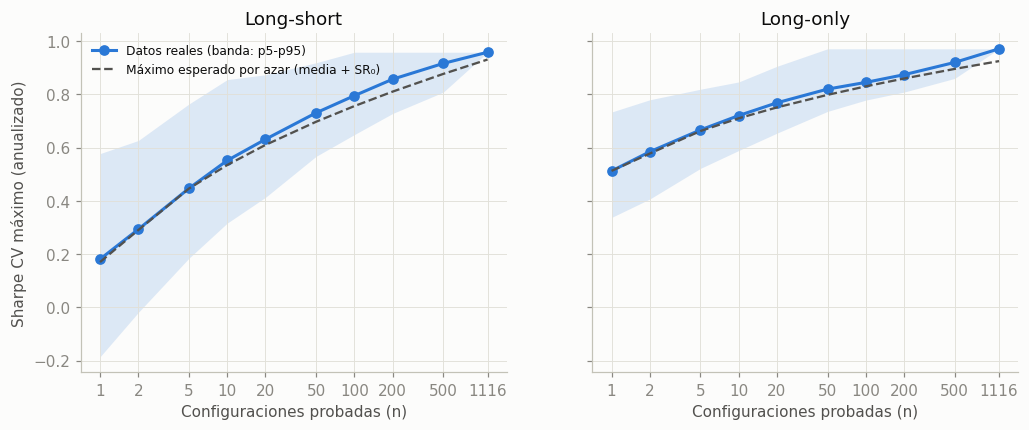

In [28]:
# Entregable 1: máximo Sharpe CV en función de la cantidad de configuraciones probadas
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, side in zip(axes, ['ls', 'lo']):
    real, teo = curves[f'real_{side}'], curves[f'teoria_{side}']
    ax.fill_between(real.index, real['p05'], real['p95'], color=COLORS['RF'], alpha=0.15, linewidth=0)
    ax.plot(real.index, real['mean'], color=COLORS['RF'], marker='o', label='Datos reales (banda: p5-p95)')
    if f'placebo_{side}' in curves:
        pla = curves[f'placebo_{side}']
        ax.plot(pla.index, pla['mean'], color=COLORS['Placebo'], marker='o', label='Placebo')
    ax.plot(teo.index, teo['mean'], color=COLORS['Teoría'], linestyle='--', linewidth=1.5,
            label='Máximo esperado por azar (media + SR₀)')
    ax.set_xscale('log')
    ax.set_xticks(real.index)
    ax.set_xticklabels([str(n) for n in real.index])
    ax.minorticks_off()
    ax.set_xlabel('Configuraciones probadas (n)')
    ax.set_title('Long-short' if side == 'ls' else 'Long-only')
axes[0].set_ylabel('Sharpe CV máximo (anualizado)')
axes[0].legend(loc='upper left', fontsize=8)
fig.savefig(RESULTS_DIR / 'fig1_max_sharpe_vs_n.png')
plt.show()

In [29]:
# Entregable 6: Sharpe CV máximo de cada repetición del placebo contra el de los datos reales
if not PLA:
    print('Sin placebo (RUN_PLACEBO = False): no se genera la figura 6.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 2.8))
    jitter = rng_for(STREAM_CURVE, 999).uniform(-0.15, 0.15, len(placebo_summary))  # solo para separar los puntos
    for ax, side in zip(axes, ['ls', 'lo']):
        ax.scatter(placebo_summary[f'max_sharpe_val_{side}'], jitter, s=50, color=COLORS['Placebo'], zorder=3,
                   label='Placebo (máximo de cada repetición)')
        ax.axvline(metrics[f'sharpe_val_{side}'].max(), color=COLORS['RF'], linewidth=2, label='Datos reales')
        ax.set_yticks([])
        ax.set_ylim(-0.6, 0.6)
        ax.grid(False, axis='y')
        ax.set_xlabel('Sharpe CV máximo (anualizado)')
        ax.set_title('Long-short' if side == 'ls' else 'Long-only')
    axes[0].legend(loc='upper left', fontsize=8)
    fig.savefig(RESULTS_DIR / 'fig6_placebo_max_sharpe.png')
    plt.show()

Sin placebo (RUN_PLACEBO = False): no se genera la figura 6.


## 12. Hold-out (2018–2025)

Solo corre con `RUN_HELDOUT = True`. Para ese momento, la selección (sección 11) ya quedó fijada con datos de train, y el chequeo 7 ya verificó que la validación da exactamente lo mismo con y sin los datos del hold-out.

- Agrega a `metrics_real.csv` las métricas de hold-out de todas las configuraciones.
- Calcula el Spearman entre el ranking de CV y el del hold-out, y la caída de la elegida contra la caída promedio (la diferencia es la parte atribuible a la selección).
- Guarda `HELDOUT_EVALUATED.json` con la fecha de la primera evaluación.

In [30]:
def heldout_metrics(base_ho):
    """Agrega las métricas de hold-out a `metrics` y guarda las matrices de retornos del hold-out."""
    HO = collect('real', GRID, 'heldout')
    rf_ho, one_n_ho = RF_M[HO_MONTHS], base_ho['1/N'][0]
    metrics['auc_ho'] = [float(HO[i]['auc']) for i in IDS]
    metrics['sharpe_ho_ls'] = [sharpe(HO[i]['ls']) * ANN for i in IDS]
    metrics['sharpe_ho_lo'] = [sharpe(HO[i]['lo'] - rf_ho) * ANN for i in IDS]
    metrics['sharpe_ho_lo1n'] = [information_ratio(HO[i]['lo'], one_n_ho) for i in IDS]
    metrics['maxdd_ho_ls'] = [max_drawdown(HO[i]['ls']) for i in IDS]
    metrics['maxdd_ho_lo'] = [max_drawdown(HO[i]['lo']) for i in IDS]
    metrics['turnover_ho_ls'] = [annual_turnover(HO[i]['to_ls']) for i in IDS]
    metrics['turnover_ho_lo'] = [annual_turnover(HO[i]['to_lo']) for i in IDS]
    metrics.to_csv(RESULTS_DIR / 'metrics_real.csv', index=False)
    np.savez_compressed(RESULTS_DIR / 'matrices_heldout.npz', ids=np.array(IDS), ho_ls=stack(HO, GRID, 'ls'),
                        ho_lo_excess=stack(HO, GRID, 'lo') - rf_ho[:, None],
                        ho_lo_vs_1n=stack(HO, GRID, 'lo') - one_n_ho[:, None])
    return HO


def heldout_series(HO, base_ho, cid, side):
    """Serie mensual del hold-out con la que se mide cada lado: LS directo, LO en exceso del T-bill, LO contra 1/N."""
    if side == 'ls':
        return HO[cid]['ls']
    return HO[cid]['lo'] - (RF_M[HO_MONTHS] if side == 'lo' else base_ho['1/N'][0])


def heldout_analysis(HO, base_ho):
    """Spearman entre rankings, y caída de la elegida contra la caída promedio de todas las configuraciones."""
    out = {}
    for side in ['ls', 'lo', 'lo1n']:
        rho, p_value = stats.spearmanr(metrics[f'sharpe_val_{side}'], metrics[f'sharpe_ho_{side}'])
        out[f'spearman_{side}'] = {'rho': float(rho), 'p_value': float(p_value)}
        j = selection[f'global_{side}']['idx']
        sel_val, sel_ho = metrics.loc[j, f'sharpe_val_{side}'], metrics.loc[j, f'sharpe_ho_{side}']
        avg_val, avg_ho = metrics[f'sharpe_val_{side}'].mean(), metrics[f'sharpe_ho_{side}'].mean()
        x = heldout_series(HO, base_ho, IDS[j], side)
        out[f'degradacion_{side}'] = {
            'id': IDS[j], 'sharpe_val_elegida': sel_val, 'sharpe_ho_elegida': sel_ho, 'caida_elegida': sel_val - sel_ho,
            'sharpe_val_promedio': avg_val, 'sharpe_ho_promedio': avg_ho, 'caida_promedio': avg_val - avg_ho,
            'caida_atribuible_a_la_seleccion': (sel_val - sel_ho) - (avg_val - avg_ho),
            'psr_ho_elegida': psr(sharpe(x), len(x), float(stats.skew(x)), float(stats.kurtosis(x, fisher=False))),
        }
    save_json(out, RESULTS_DIR / 'heldout_analysis.json')
    return out


def heldout_plots(HO, base_ho):
    # Entregable 4: ranking de CV contra ranking del hold-out
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, side in zip(axes, ['ls', 'lo']):
        r_val = stats.rankdata(metrics[f'sharpe_val_{side}'])
        r_ho = stats.rankdata(metrics[f'sharpe_ho_{side}'])
        rho, _ = stats.spearmanr(r_val, r_ho)
        j = selection[f'global_{side}']['idx']
        ax.scatter(r_val, r_ho, s=8, color=COLORS['RF'], alpha=0.5)
        ax.scatter([r_val[j]], [r_ho[j]], s=60, color=INK['primary'], zorder=3)
        ax.annotate('elegida', (r_val[j], r_ho[j]), textcoords='offset points', xytext=(-50, 6),
                    color=INK['secondary'])
        ax.set_xlabel('Ranking por Sharpe CV')
        ax.set_ylabel('Ranking por Sharpe en hold-out')
        ax.set_title(f"{'Long-short' if side == 'ls' else 'Long-only'} (Spearman = {rho:.2f})")
    fig.savefig(RESULTS_DIR / 'fig4_ranking_cv_vs_heldout.png')
    plt.show()

    # Entregable 5: valor acumulado en el hold-out, neto de costos
    x = ALL_MONTHS[HO_MONTHS].to_timestamp()
    j_lo, j_ls = selection['global_lo']['idx'], selection['global_ls']['idx']
    panels = [('Long-only', {'RF': HO[IDS[j_lo]]['lo'], '1/N': base_ho['1/N'][0],
                             'Risk parity': base_ho['Risk parity'][0], 'SPY': base_ho['SPY'][0]}),
              ('Long-short', {'RF': HO[IDS[j_ls]]['ls'], 'Momentum 12-1': base_ho['Momentum 12-1'][0]})]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
    for ax, (title, series) in zip(axes, panels):
        for name, r in series.items():
            ax.plot(x, np.cumprod(1.0 + r), color=COLORS[name], label='RF elegida' if name == 'RF' else name)
        ax.axhline(1.0, color=INK['axis'], linewidth=1)
        ax.set_title(title)
        ax.legend(loc='upper left')
    axes[0].set_ylabel('Valor de 1 USD invertido')
    fig.savefig(RESULTS_DIR / 'fig5_acumulado_heldout.png')
    plt.show()

In [31]:
if not RUN_HELDOUT:
    print('RUN_HELDOUT = False: el hold-out no se evalúa. Cambiarlo a True recién cuando todo lo anterior esté verificado.')
else:
    marker = RESULTS_DIR / 'HELDOUT_EVALUATED.json'
    if marker.exists():
        print(f"Atención: el hold-out ya se evaluó el {load_json(marker)['first_evaluated']}. "
              'Los resultados se recalculan idénticos.')
    else:
        save_json({'first_evaluated': time.strftime('%Y-%m-%d %H:%M:%S'), 'run_tag': RUN_TAG}, marker)
    BASE_HO = baseline_returns(world_real, HO_MONTHS)
    baselines_ho = baseline_table(BASE_HO, RF_M[HO_MONTHS], 'ho')
    baselines_ho.to_csv(RESULTS_DIR / 'baselines_ho.csv')
    np.savez_compressed(RESULTS_DIR / 'baselines_ho_returns.npz',
                        **{k.replace('/', '_'): v[0] for k, v in BASE_HO.items()})
    HO = heldout_metrics(BASE_HO)
    HO_ANALYSIS = heldout_analysis(HO, BASE_HO)
    heldout_plots(HO, BASE_HO)
    display(pd.DataFrame(HO_ANALYSIS).T)

RUN_HELDOUT = False: el hold-out no se evalúa. Cambiarlo a True recién cuando todo lo anterior esté verificado.


## 13. Entregables

Tablas 2 y 3 del plan. Las columnas de hold-out aparecen recién al correr con `RUN_HELDOUT = True`. Las figuras 1 y 6 están en la sección 11 (la 6 solo con placebo), y la 4 y la 5 en la sección 12 (solo con hold-out).

- `sharpe_train_is`: modelo final evaluado sobre sus propios datos de entrenamiento (in-sample).
- `sharpe_val`: serie OOS de la purged CV (2006–2017). Para los baselines, que no se entrenan, es su Sharpe de 2006–2017.
- `dsr_val`: DSR de la elegida, calculado con el N efectivo (`N_eff`). Para los baselines es el PSR, porque son un solo intento.
- En la fila `LO contra 1/N`, los Sharpe son information ratios contra 1/N (Sharpe del retorno activo) y el DSR se calcula sobre ese retorno activo.

In [32]:
SIDE_LABEL = {'ls': 'LS', 'lo': 'LO', 'lo1n': 'LO contra 1/N'}


def main_table():
    """Entregable 2: las elegidas (LS, LO y LO contra 1/N), el promedio de las configuraciones y los baselines."""
    has_ho = 'sharpe_ho_ls' in metrics
    rows = []
    for side in ['ls', 'lo', 'lo1n']:
        s = selection[f'global_{side}']
        j = s['idx']
        port = 'lo' if side == 'lo1n' else side  # la elegida contra 1/N también es una cartera long-only
        row = {'estrategia': f'RF elegida ({SIDE_LABEL[side]})', 'config': s['id'],
               'sharpe_train_is': metrics.loc[j, f'sharpe_train_{side}'],
               'sharpe_val': metrics.loc[j, f'sharpe_val_{side}'],
               'N_eff': s['N_eff'], 'dsr_val': s['dsr'], 'dsr_val_T_eff': s['dsr_T_eff'],
               'pbo': PBO[f'global_{side}_sharpe']['pbo'],
               'maxdd_val': metrics.loc[j, f'maxdd_val_{port}'],
               'turnover_val': metrics.loc[j, f'turnover_val_{port}'],
               'ir_vs_1N_val': metrics.loc[j, 'sharpe_val_lo1n'] if side == 'lo' else np.nan}
        if has_ho:
            row.update(sharpe_ho=metrics.loc[j, f'sharpe_ho_{side}'],
                       psr_ho=HO_ANALYSIS[f'degradacion_{side}']['psr_ho_elegida'],
                       maxdd_ho=metrics.loc[j, f'maxdd_ho_{port}'],
                       ir_vs_1N_ho=metrics.loc[j, 'sharpe_ho_lo1n'] if side == 'lo' else np.nan)
        rows.append(row)
    for side in ['ls', 'lo', 'lo1n']:
        row = {'estrategia': f'Promedio de las configuraciones ({SIDE_LABEL[side]})',
               'sharpe_train_is': metrics[f'sharpe_train_{side}'].mean(),
               'sharpe_val': metrics[f'sharpe_val_{side}'].mean()}
        if has_ho:
            row['sharpe_ho'] = metrics[f'sharpe_ho_{side}'].mean()
        rows.append(row)
    for name in BASE_VAL:  # para los baselines, sharpe_val es el Sharpe de 2006-2017 y su DSR es el PSR (N = 1)
        row = {'estrategia': name, 'sharpe_val': baselines_val.loc[name, 'sharpe_val'],
               'dsr_val': baselines_val.loc[name, 'psr_val'], 'maxdd_val': baselines_val.loc[name, 'maxdd_val'],
               'turnover_val': baselines_val.loc[name, 'turnover_val'],
               'ir_vs_1N_val': baselines_val.loc[name, 'ir_vs_1N_val']}
        if has_ho:
            row.update(sharpe_ho=baselines_ho.loc[name, 'sharpe_ho'], psr_ho=baselines_ho.loc[name, 'psr_ho'],
                       maxdd_ho=baselines_ho.loc[name, 'maxdd_ho'], ir_vs_1N_ho=baselines_ho.loc[name, 'ir_vs_1N_ho'])
        rows.append(row)
    return pd.DataFrame(rows).set_index('estrategia')


def criteria_table():
    """Entregable 3: por grupo (h, cuantil) y por LS/LO, la elegida por Sharpe contra la elegida por AUC."""
    has_ho = 'sharpe_ho_ls' in metrics
    rows = []
    for h, q in GROUPS:
        for side in ['ls', 'lo']:
            for crit in ['sharpe', 'auc']:
                s = selection[f'h{h}_q{q}_{side}_{crit}']
                j = s['idx']
                row = {'grupo': f'h={h}, q={q}', 'side': side.upper(), 'criterio': crit, 'config': s['id'],
                       'auc_val': metrics.loc[j, 'auc_val'], 'sharpe_val': metrics.loc[j, f'sharpe_val_{side}'],
                       'N_eff': s['N_eff'], 'dsr_val': s['dsr'], 'dsr_bien_especificado': crit == 'sharpe',
                       'pbo': PBO[f'h{h}_q{q}_{side}_{crit}']['pbo']}
                if has_ho:
                    row.update(sharpe_ho=metrics.loc[j, f'sharpe_ho_{side}'],
                               caida=metrics.loc[j, f'sharpe_val_{side}'] - metrics.loc[j, f'sharpe_ho_{side}'])
                rows.append(row)
    return pd.DataFrame(rows)


table_main, table_criteria = main_table(), criteria_table()
table_main.to_csv(RESULTS_DIR / 'tabla_principal.csv')
table_criteria.to_csv(RESULTS_DIR / 'tabla_criterios.csv', index=False)
display(table_main.round(3))
display(table_criteria.round(3))

,config,sharpe_train_is,sharpe_val,N_eff,dsr_val,dsr_val_T_eff,pbo,maxdd_val,turnover_val,ir_vs_1N_val
estrategia,,,,,,,,,,
RF elegida (LS),m16_h6_q5_d2_l1,1.067,0.958,464.197,0.804,0.780,0.168,0.176,2.980,NaN
RF elegida (LO),m16_h6_q5_d8_l1,0.966,0.971,104.478,0.981,0.971,0.064,0.482,1.981,1.006
RF elegida (LO contra 1/N),m16_h6_q5_d8_l1,1.052,1.006,524.219,0.856,0.856,0.168,0.482,1.981,NaN
Promedio de las configuraciones (LS),NaN,0.762,0.170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Promedio de las configuraciones (LO),NaN,0.738,0.513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Promedio de las configuraciones (LO contra 1/N),NaN,0.704,0.179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1/N,NaN,NaN,0.627,NaN,0.979,NaN,NaN,0.523,0.412,NaN
Risk parity,NaN,NaN,0.694,NaN,0.987,NaN,NaN,0.464,0.520,-0.091
Momentum 12-1,NaN,NaN,-0.149,NaN,0.299,NaN,NaN,0.668,6.050,NaN


,grupo,side,criterio,config,auc_val,sharpe_val,N_eff,dsr_val,dsr_bien_especificado,pbo
0,"h=1, q=3",LS,sharpe,m16_h1_q3_d2_l1,0.529,0.666,82.617,0.678,True,0.236
1,"h=1, q=3",LS,auc,m28_h1_q3_d4_l50,0.550,0.128,82.617,0.074,False,0.477
2,"h=1, q=3",LO,sharpe,m16_h1_q3_d2_l1,0.529,0.779,14.180,0.979,True,0.116
3,"h=1, q=3",LO,auc,m28_h1_q3_d4_l50,0.550,0.454,14.180,0.829,False,0.641
4,"h=1, q=5",LS,sharpe,m16_h1_q5_d8_l1,0.540,0.855,61.775,0.970,True,0.061
5,"h=1, q=5",LS,auc,m28_h1_q5_d4_l50,0.584,0.179,61.775,0.149,False,0.361
6,"h=1, q=5",LO,sharpe,m16_h1_q5_d2_l1,0.547,0.793,16.792,0.988,True,0.081
7,"h=1, q=5",LO,auc,m28_h1_q5_d4_l50,0.584,0.379,16.792,0.748,False,0.671
8,"h=3, q=3",LS,sharpe,m22_h3_q3_d4_l1,0.538,0.772,78.011,0.721,True,0.205
9,"h=3, q=3",LS,auc,m24_h3_q3_d2_l1,0.552,0.247,78.011,0.099,False,0.287


In [33]:
print(f'Resultados en {RESULTS_DIR.relative_to(BASE_DIR)}')
for p in sorted(RESULTS_DIR.iterdir()):
    print(f'  {p.name:45s} {p.stat().st_size / 1024:10.1f} KB')
print(f'Caché por configuración en {CACHE_DIR.relative_to(BASE_DIR)}')

Resultados en results\fa3e6998e744_full
  availability.csv                                    22.9 KB
  baselines_val.csv                                    0.4 KB
  baselines_val_returns.npz                            5.3 KB
  curva_max_sharpe.csv                                 1.6 KB
  fig1_max_sharpe_vs_n.png                            78.1 KB
  manifest.json                                        2.9 KB
  matrices_real.npz                                 4089.7 KB
  metrics_real.csv                                   319.0 KB
  pbo.csv                                              2.1 KB
  pbo_logits.npz                                      74.0 KB
  pip_freeze.txt                                       1.4 KB
  runs_log.jsonl                                       2.1 KB
  selection.csv                                        6.7 KB
  tabla_criterios.csv                                  3.3 KB
  tabla_principal.csv                                  1.3 KB
  universe.csv                